# Frame Detection — Results Analysis & Visualization

This notebook analyzes the output of the frame-detection pipeline (`framing_chat_6_frames_events_revised_v7.ipynb`)
across one or more models. It is designed to work directly with the flattened CSV outputs produced by that
pipeline (`frames_<dataset_stem>_<model_slug>.csv`), including:

- The single-model run outputs in `./data/`
- The multi-model comparison outputs in `./data/frame_model_comparison/<model_slug>/`

It produces:

1. **Comparative statistics on `frame_label`** (NOT_FRAMED / SINGLE_FRAME / MULTIPLE_FRAMES) across models.
2. **Detailed and aggregate statistics on `frame_type`** (the 12 frame×polarity categories), per model and across
   models.
3. **Positive vs. negative polarity visualizations** for each of the 6 substantive frames.
4. **Frame type over time, by model**, including a polarity × time view (polarity on one axis, time on the other),
   provided a date-like column is available in the input data.

Nothing here re-runs the LLM — it only reads and analyzes the CSVs already produced.


**Updated edition:** adds segment-level metadata associations for relevance, gender and calendar decade, six base frames and twelve signed frames, matched-model comparisons, document bootstrap intervals, clustered logistic tests, joint adjustment and saved visualizations. Outputs are cleared for a fresh run. The original CSVs were not accessible during creation; validation used synthetic data.


## Configuration

Edit `DATA_DIR` / `EXTRA_PATHS` if your outputs live somewhere else. By default this notebook auto-discovers
every `frames_*.csv` file under `DATA_DIR` (single-model runs) and under
`DATA_DIR/frame_model_comparison/*/` (the model-comparison run), then combines them.

If you'd rather point at specific files/models explicitly, set `MANUAL_FILES` to a dict of
`{model_name: path_to_csv}` and it will be used instead of auto-discovery.


In [1]:

import glob
import json
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Warnings remain visible; statistical fits below capture and record diagnostics.
sns.set_theme(style="whitegrid", font_scale=1.0)

# --- Frame taxonomy (must match the detection notebook) ---------------------
FRAME_NAMES = ["modernization", "patriotism", "victimhood", "moral", "economic", "diplomacy"]
POLARITIES = ["positive", "negative"]
FRAME_TYPE_ORDER = [f"{f} ({p})" for f in FRAME_NAMES for p in POLARITIES]
FRAME_LABEL_ORDER = ["NOT_FRAMED", "SINGLE_FRAME", "MULTIPLE_FRAMES"]

# --- Where to look for outputs -----------------------------------------------
DATA_DIR = Path("/Users/carmand/Desktop/framing")

# Optional: bypass auto-discovery entirely by filling this in, e.g.
# MANUAL_FILES = {
#     "qwen3.5:35b": "./data/frames_sample_relevant_qwen3.5_35b.csv",
#     "llama3.3:70b": "./data/frame_model_comparison/llama3.3_70b/frames_sample_relevant_llama3.3_70b.csv",
# }
MANUAL_FILES: dict[str, str] = {
    "Gemma 3 27B": str(DATA_DIR / "frames_debate_complete_gemma3_27b.csv"),
    "Qwen 3.5 35B": str(DATA_DIR / "frames_debate_complete_qwen3.5_35b.csv"),
}

print(f"Data directory: {DATA_DIR.resolve()}")

# Additional metadata associations (sections at the end of this notebook).
ASSOC_OUTPUT_DIR = Path('./analysis_outputs/metadata_associations')
ASSOC_VARIABLES = ['relevance_to_original_topic', 'gender_mentioned', 'decade']
ASSOC_JOIN_KEYS = None  # Auto: _row_id, otherwise doc_id + segment_index.
ASSOC_REFERENCE_MODEL = None  # None = first model in sorted order.
ASSOC_LEVEL_REFERENCES = {}  # Optional variable:reference level for regression.
ASSOC_MIN_CLUSTERS = 30  # Suppress asymptotic robust tests with fewer documents.
ASSOC_MIN_CELL = 5  # Suppress separated/sparse categorical logistic fits.
ASSOC_BOOTSTRAPS = 500  # Increase to 2000 for final reporting.
ASSOC_SEED = 42
ASSOC_ALPHA = 0.05
ASSOC_ADJUSTED_MODELS = True  # Adjust jointly for relevance, gender, and decade.
ASSOC_MAKE_PLOTS = True
ASSOC_MAX_PLOT_LEVELS = 30  # Tables always retain every level.
ASSOC_MISSING_TOKENS = {''}  # Do not treat a valid 'NONE' gender category as missing.


Data directory: /Users/carmand/Desktop/framing


In [2]:

def discover_frame_csvs(data_dir: Path) -> list[Path]:
    # Find flattened frame-detection CSVs: single-model runs directly under
    # data_dir, and per-model runs under data_dir/frame_model_comparison/*/.
    patterns = [
        str(data_dir / "frames_*.csv"),
        str(data_dir / "frame_model_comparison" / "*" / "frames_*.csv"),
        str(data_dir / "frame_model_comparison" / "*" / "*.csv"),
    ]
    found: list[Path] = []
    for pat in patterns:
        found.extend(Path(p) for p in glob.glob(pat))
    # de-duplicate while preserving order
    seen = set()
    unique = []
    for p in found:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            unique.append(p)
    return sorted(unique)


if MANUAL_FILES:
    discovered = [Path(p) for p in MANUAL_FILES.values()]
    print("Using MANUAL_FILES:")
    for model, p in MANUAL_FILES.items():
        print(f"  {model}: {p}")
else:
    discovered = discover_frame_csvs(DATA_DIR)
    print(f"Discovered {len(discovered)} CSV file(s):")
    for p in discovered:
        print(" ", p)

assert discovered, (
    "No frame-detection CSVs found. Point DATA_DIR at the right folder, "
    "or fill in MANUAL_FILES explicitly."
)


Using MANUAL_FILES:
  Gemma 3 27B: /Users/carmand/Desktop/framing/frames_debate_complete_gemma3_27b.csv
  Qwen 3.5 35B: /Users/carmand/Desktop/framing/frames_debate_complete_qwen3.5_35b.csv


## Load, clean, and reshape

Each row of a flattened output CSV represents one segment as scored by one model. `frame_type` is a
`|`-joined string like `"patriotism (positive)|economic (negative)"` (empty when `NOT_FRAMED`).

We:
- load every discovered CSV and tag it with its model (from `framing_model`, falling back to the file/folder name),
- drop rows flagged with `frame_processing_error == TRUE` (failed LLM calls carry no usable label),
- try to detect a date-like column so we can do the time-based analysis in Section 5,
- build a **long-format** table (`exploded`) with one row per *(segment, frame_type)* pair, splitting
  `frame_type` into `frame_name` + `polarity`, which is what most of the plots below use.


In [3]:

def model_name_from_path(path: Path) -> str:
    # e.g. .../frame_model_comparison/llama3.3_70b/frames_..._llama3.3_70b.csv -> "llama3.3_70b"
    if path.parent.name and path.parent.name != DATA_DIR.name:
        return path.parent.name
    m = re.search(r"frames_.+?_([A-Za-z0-9._-]+)\.csv$", path.name)
    return m.group(1) if m else path.stem


frames = []
for p in discovered:
    d = pd.read_csv(p, keep_default_na=False, dtype=str)
    d["_source_file"] = str(p)
    manual_name = next((name for name, location in MANUAL_FILES.items()
                        if Path(location).resolve() == p.resolve()), None)
    d["_manual_model"] = manual_name or ""
    frames.append(d)

raw = pd.concat(frames, ignore_index=True, sort=False)
print(f"Loaded {len(raw):,} rows total across {len(discovered)} file(s).")
print("Columns:", list(raw.columns))

# Prefer the model recorded by the pipeline itself; fall back to path-derived name.
if "framing_model" in raw.columns and raw["framing_model"].str.strip().ne("").any():
    raw["model"] = raw["framing_model"].where(
        raw["framing_model"].str.strip().ne(""),
        raw["_source_file"].apply(lambda s: model_name_from_path(Path(s))),
    )
else:
    raw["model"] = raw["_source_file"].apply(lambda s: model_name_from_path(Path(s)))

print("\\nRows per model (before filtering errors):")
print(raw["model"].value_counts())

# Explicit MANUAL_FILES names take priority over pipeline names.
raw['model'] = raw['_manual_model'].where(raw['_manual_model'].ne(''), raw['model'])
raw = raw.fillna('')


Loaded 9,268 rows total across 2 file(s).
Columns: ['Unnamed: 0', 'doc_id', 'date', 'title', 'source', 'segmentation_label', 'segmentation_confidence', 'segmentation_explanation', 'processing_error', 'segment_index', 'segment_text', 'segment_verbatim', 'topic_type', 'topic_policy', 'topic_debate', 'topic_biography', 'topic_organization', 'topic_other', 'relevance_to_original_topic', 'relevance_evidence', 'gender_mentioned', 'gender_evidence', 'year', '_input_row_number', '_row_id', 'frame_label', 'frame_type', 'frame_explanation', 'frame_evidence', 'frame_evidence_grounded', 'frame_evidence_error', 'framing_actors', 'framed_actors', 'framed_events', 'framing_confidence', 'frame_processing_error', 'frame_processing_error_type', 'framing_model', '_source_file', '_manual_model']
\nRows per model (before filtering errors):
model
gemma3:27b     4634
qwen3.5:35b    4634
Name: count, dtype: int64


In [4]:

# Drop rows where the LLM call itself failed — no usable frame_label/frame_type.
if "frame_processing_error" in raw.columns:
    is_error = raw["frame_processing_error"].astype(str).str.upper().eq("TRUE")
    n_err = int(is_error.sum())
    ok = raw.loc[~is_error].copy()
    print(f"Dropped {n_err:,} row(s) with frame_processing_error=TRUE.")
else:
    ok = raw.copy()

# Numeric confidence.
if "framing_confidence" in ok.columns:
    ok["framing_confidence"] = pd.to_numeric(ok["framing_confidence"], errors="coerce")

# Normalize frame_label to the expected categorical order (unexpected/blank -> keep as-is, shown separately).
ok["frame_label"] = ok["frame_label"].astype(str).str.strip()

print(f"\\nUsable rows: {len(ok):,}")
print(ok["frame_label"].value_counts())


Dropped 13 row(s) with frame_processing_error=TRUE.
\nUsable rows: 9,255
frame_label
MULTIPLE_FRAMES    7038
SINGLE_FRAME       1762
NOT_FRAMED          455
Name: count, dtype: int64


In [5]:
# Parse compact/ISO dates explicitly, with integer year fallback.
DATE_COLUMN_CANDIDATES = ['date', 'pub_date', 'publish_date', 'publication_date',
                          'article_date', 'issue_date', 'issue', 'year']
date_col = next((c for c in DATE_COLUMN_CANDIDATES if c in ok), None)
ok['_date'] = pd.NaT
if date_col and date_col != 'year':
    text = ok[date_col].astype(str).str.strip()
    ok['_date'] = pd.to_datetime(text, format='%Y%m%d', errors='coerce').fillna(
        pd.to_datetime(text, format='%Y-%m-%d', errors='coerce'))
year_fallback = pd.to_numeric(ok['year'], errors='coerce') if 'year' in ok else pd.Series(np.nan,index=ok.index)
year_fallback = year_fallback.where(year_fallback.between(1000,9999) & year_fallback.mod(1).eq(0))
ok['_year'] = ok['_date'].dt.year.fillna(year_fallback)
print(f'Parsed year for {int(ok._year.notna().sum()):,}/{len(ok):,} eligible legacy rows.')


Parsed year for 9,255/9,255 eligible legacy rows.


In [6]:

# --- Long format: one row per (segment, frame_type) pair -------------------
ok["frame_type"] = ok["frame_type"].fillna("").astype(str)

exploded = ok.assign(frame_type_single=ok["frame_type"].str.split("|")).explode("frame_type_single")
exploded["frame_type_single"] = exploded["frame_type_single"].str.strip()
exploded = exploded[exploded["frame_type_single"] != ""].copy()


def split_frame_polarity(value: str):
    m = re.match(r"^(.*)\s\((positive|negative)\)$", value)
    return (m.group(1), m.group(2)) if m else (value, None)


_split = exploded["frame_type_single"].apply(split_frame_polarity)
exploded["frame_name"] = _split.apply(lambda t: t[0])
exploded["polarity"] = _split.apply(lambda t: t[1])

# Keep a tidy, ordered categorical for nicer plots/tables.
exploded["frame_name"] = pd.Categorical(exploded["frame_name"], categories=FRAME_NAMES, ordered=True)
exploded["polarity"] = pd.Categorical(exploded["polarity"], categories=POLARITIES, ordered=True)

MODEL_ORDER = sorted(ok["model"].unique())
ok["model"] = pd.Categorical(ok["model"], categories=MODEL_ORDER, ordered=True)
exploded["model"] = pd.Categorical(exploded["model"], categories=MODEL_ORDER, ordered=True)

print(f"Exploded table: {len(exploded):,} (segment, frame_type) rows across {len(MODEL_ORDER)} model(s): {MODEL_ORDER}")
exploded[["model", "frame_type_single", "frame_name", "polarity"]].head()


Exploded table: 21,686 (segment, frame_type) rows across 2 model(s): ['Gemma 3 27B', 'Qwen 3.5 35B']


,model,frame_type_single,frame_name,polarity
0,Gemma 3 27B,patriotism (positive),patriotism,positive
1,Gemma 3 27B,modernization (negative),modernization,negative
1,Gemma 3 27B,victimhood (positive),victimhood,positive
1,Gemma 3 27B,economic (negative),economic,negative
2,Gemma 3 27B,modernization (negative),modernization,negative


In [7]:

TIME_BIN_YEARS = 5  # widen/narrow the time buckets here

dated = exploded.dropna(subset=['_year']).copy()
has_time = not dated.empty

if not has_time:
    dated['year_bin'] = pd.Series(dtype=int)
    year_bins = []
    print("No usable date information was found — skipping the time-based analysis.")
else:
    dated = exploded.dropna(subset=["_year"]).copy()
    dated["_year"] = dated["_year"].astype(int)
    min_year, max_year = int(dated["_year"].min()), int(dated["_year"].max())
    bin_start = (min_year // TIME_BIN_YEARS) * TIME_BIN_YEARS
    dated["year_bin"] = (dated["_year"] // TIME_BIN_YEARS * TIME_BIN_YEARS).astype(int)
    print(f"Date range: {min_year}-{max_year}. Binning into {TIME_BIN_YEARS}-year buckets "
          f"({dated['year_bin'].nunique()} bucket(s)).")

year_bins = sorted(dated["year_bin"].unique()) if has_time else []


Date range: 1873-1949. Binning into 5-year buckets (16 bucket(s)).


## Frame detection — comparative statistics across models

`frame_label` is the coarse count category per segment: `NOT_FRAMED`, `SINGLE_FRAME`, or `MULTIPLE_FRAMES`.


In [ ]:

label_counts = (
    ok.groupby(["model", "frame_label"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(columns=FRAME_LABEL_ORDER, fill_value=0)
      .reindex(MODEL_ORDER)
)
label_props = label_counts.div(label_counts.sum(axis=1), axis=0)

print("Counts:")
display(label_counts)
print("\\nRow-wise proportions:")
display(label_props.round(3))


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

label_counts.plot(kind="bar", ax=axes[0], colormap="viridis", edgecolor="white")
axes[0].set_title("frame_label — raw counts by model")
axes[0].set_ylabel("Segments")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="frame_label")

label_props.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="white")
axes[1].set_title("frame_label — share of segments by model")
axes[1].set_ylabel("Share")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="frame_label", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:

# Pairwise agreement on frame_label for segments scored by >=2 models (only meaningful
# when the same _row_id was scored by multiple models, e.g. the model-comparison run).
if "_row_id" in ok.columns and ok["model"].nunique() > 1:
    pivot = ok.pivot_table(index="_row_id", columns="model", values="frame_label", aggfunc="first", observed=True)
    common = pivot.dropna()
    if len(common) > 0:
        agree = common.nunique(axis=1) == 1
        print(f"Segments scored by all {pivot.shape[1]} model(s): {len(common):,}")
        print(f"Exact frame_label agreement across all models: {agree.mean():.1%}")
    else:
        print("No segments were scored by all models (models were likely run on different rows) — skipping agreement check.")
else:
    print("Only one model present (or no _row_id column) — skipping cross-model agreement check.")


## Frame classification (1) — detailed and aggregate statistics

Each substantive `frame_type` is one of the 12 frame × polarity combinations. A segment can contribute to more
than one `frame_type` (when `frame_label == MULTIPLE_FRAMES`), so counts here are **frame-type incidences**,
not segment counts.


In [ ]:

# --- Detailed: per-model frame_type counts & shares -------------------------
type_counts = (
    exploded.groupby(["model", "frame_type_single"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
            .reindex(MODEL_ORDER)
)

# Share of each model's own frame-type incidences (columns sum to 1 within a model... 
# here we show share of that model's total incidences, i.e. rows sum to 1).
type_shares = type_counts.div(type_counts.sum(axis=1), axis=0) * 100

print("frame_type counts by model:")
display(type_counts)
print("\\nframe_type shares by model (of that model's own frame-type incidences):")
display(type_shares.round(3))


In [ ]:

# --- Aggregate: across all models combined ----------------------------------
type_counts_agg = (
    exploded.groupby("frame_type_single", observed=True)
            .size()
            .reindex(FRAME_TYPE_ORDER, fill_value=0)
            .rename("count")
            .to_frame()
)
type_counts_agg["share"] = type_counts_agg["count"] / type_counts_agg["count"].sum() * 100

print("frame_type counts aggregated across all models:")
display(type_counts_agg.sort_values("count", ascending=False).round({"share": 3}))


In [ ]:

fig, ax = plt.subplots(figsize=(11, 5))
order = type_counts_agg.sort_values("count", ascending=False).index
type_counts.T.reindex(order).plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("frame_type incidence counts, by model")
ax.set_ylabel("Incidences")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=60)
ax.legend(title="model")
plt.tight_layout()
plt.show()


Let's visualize the results as a heatmap (matrix) of frame_type × model, with counts in each cell. This is a more compact way to see the same information as the bar chart above.

In [ ]:

plot_data = (
    type_counts
    .T
    .reindex(FRAME_TYPE_ORDER)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
    .astype(int)
)

# Much wider figure
fig, ax = plt.subplots(
    figsize=(5 * len(plot_data.columns), 8)
)

# Draw heatmap WITHOUT seaborn annotations
sns.heatmap(
    plot_data,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "incidences"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually add value to EVERY cell
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:,}",       # e.g. 3,192
            ha="center",
            va="center",
            fontsize=10,
            color="white",
        )

ax.set_title("frame_type × model — incidence counts", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis model names
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

# Keep all y-axis labels visible
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

In [ ]:
# Build the heatmap with percentages instead of raw counts

plot_data = (
    type_counts
    .T
    .reindex(FRAME_TYPE_ORDER)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
)

# Percentage within each model column
plot_pct = plot_data.div(plot_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(
    figsize=(6 * len(plot_pct.columns), 9)
)

# Draw heatmap without automatic annotations
sns.heatmap(
    plot_pct,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "percentage (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually write percentage in every cell
for i in range(plot_pct.shape[0]):
    for j in range(plot_pct.shape[1]):
        value = plot_pct.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            clip_on=False,
        )

ax.set_title("frame_type × model — percentage distribution", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

## Frame classification (2) — detailed and aggregate statistics

In [ ]:
# --- Detailed: per-model frame_name counts & shares -------------------------
name_counts = (
    exploded.groupby(["model", "frame_name"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_NAMES, fill_value=0)
            .reindex(MODEL_ORDER)
)

# Share of each model's own frame-name incidences (columns sum to 1 within a model... 
# here we show share of that model's total incidences, i.e. rows sum to 1).
name_shares = name_counts.div(name_counts.sum(axis=1), axis=0) * 100

print("frame_name counts by model:")
display(name_counts)
print("\\nframe_name shares by model (of that model's own frame-name incidences):")
display(name_shares.round(3))

In [ ]:

# --- Aggregate: across all models combined ----------------------------------
name_counts_agg = (
    exploded.groupby("frame_name", observed=True)
            .size()
            .reindex(FRAME_NAMES, fill_value=0)
            .rename("count")
            .to_frame()
)
name_counts_agg["share"] = name_counts_agg["count"] / name_counts_agg["count"].sum() * 100

print("frame_name counts aggregated across all models:")
display(name_counts_agg.sort_values("count", ascending=False).round({"share": 3}))


In [ ]:

fig, ax = plt.subplots(figsize=(11, 5))
order = name_counts_agg.sort_values("count", ascending=False).index
name_counts.T.reindex(order).plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("frame_name incidence counts, by model")
ax.set_ylabel("Incidences")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=60)
ax.legend(title="model")
plt.tight_layout()
plt.show()


In [ ]:
# Visualize as a matrix

plot_data = (
    name_counts
    .T
    .reindex(FRAME_NAMES)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
    .astype(int)
)

# Much wider figure
fig, ax = plt.subplots(
    figsize=(5 * len(plot_data.columns), 8)
)

# Draw heatmap WITHOUT seaborn annotations
sns.heatmap(
    plot_data,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "incidences"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually add value to EVERY cell
for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        value = plot_data.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:,}",       # e.g. 3,192
            ha="center",
            va="center",
            fontsize=10,
            color="white",
        )

ax.set_title("frame_name × model — incidence counts", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis model names
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

# Keep all y-axis labels visible
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

In [ ]:
# Build the matrix with percentages instead of raw counts

plot_data = (
    name_counts
    .T
    .reindex(FRAME_NAMES)
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
)

# Percentage within each model column
plot_pct = plot_data.div(plot_data.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(
    figsize=(6 * len(plot_pct.columns), 9)
)

# Draw heatmap without automatic annotations
sns.heatmap(
    plot_pct,
    annot=False,
    cmap="mako_r",
    cbar_kws={"label": "percentage (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

# Manually write percentage in every cell
for i in range(plot_pct.shape[0]):
    for j in range(plot_pct.shape[1]):
        value = plot_pct.iloc[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            clip_on=False,
        )

ax.set_title("frame_name × model — percentage distribution", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

## Frame polarity

For each of the 6 substantive frames, how often is it invoked positively vs. negatively, and does that balance
differ by model?


In [ ]:

pol_counts = (
    exploded.groupby(["model", "frame_name", "polarity"], observed=True)
            .size()
            .unstack("polarity", fill_value=0)
            .reindex(columns=POLARITIES, fill_value=0)
)
pol_counts["net_positive"] = pol_counts["positive"] - pol_counts["negative"]
pol_counts["positive_share"] = pol_counts["positive"] / (pol_counts["positive"] + pol_counts["negative"]).replace(0, np.nan)

print("Positive / negative incidence counts by model and frame:")
display(pol_counts.round(3))


In [ ]:

# Diverging bar chart: negative bars to the left, positive bars to the right, one panel per model.
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6 * len(MODEL_ORDER), 4.5), sharey=True, squeeze=False)
axes = axes[0]

for ax, model in zip(axes, MODEL_ORDER):
    sub = pol_counts.loc[model].reindex(FRAME_NAMES) if model in pol_counts.index.get_level_values(0) else \
          pd.DataFrame(0, index=FRAME_NAMES, columns=["negative", "positive"])
    ax.barh(sub.index.astype(str), -sub["negative"], color="#d9534f", label="negative")
    ax.barh(sub.index.astype(str), sub["positive"], color="#5cb85c", label="positive")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(str(model))
    ax.set_xlabel("Incidences (negative \u2190  \u2192 positive)")

axes[0].set_ylabel("Frame")
axes[-1].legend(loc="lower right")
fig.suptitle("Polarity balance per frame, by model", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:

# Overall positive vs negative totals across all frames, by model — a compact summary view.
overall_pol = (
    exploded.groupby(["model", "polarity"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=POLARITIES, fill_value=0)
            .reindex(MODEL_ORDER)
)
overall_pol_share = overall_pol.div(overall_pol.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
overall_pol_share.plot(kind="bar", stacked=True, ax=ax, color=["#5cb85c", "#d9534f"], edgecolor="white")
ax.set_title("Overall positive vs. negative share, by model\n(across all frame types)")
ax.set_ylabel("Share of frame-type incidences")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="polarity")
plt.tight_layout()
plt.show()

overall_pol_share.round(3) * 100


In [ ]:

# --- Aggregate: across all models combined ----------------------------------
polarity_agg = (
    exploded.groupby("polarity", observed=True)
            .size()
            .reindex(POLARITIES, fill_value=0)
            .rename("count")
            .to_frame()
)
polarity_agg["share"] = polarity_agg["count"] / polarity_agg["count"].sum() * 100

print("polarity counts aggregated across all models:")
display(polarity_agg.sort_values("count", ascending=False).round({"share": 3}))


## Association between frame and polarity 

In [ ]:
from scipy.stats import chi2_contingency


# ============================================================
# FRAME × POLARITY ASSOCIATION
# ============================================================

POLARITY_ORDER = ["positive", "negative"]


def cramers_v(table):
    """Bias-corrected Cramér's V."""
    
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = table.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(kcorr - 1, rcorr - 1)

    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

In [ ]:
# Overall association between frame_name and polarity, across all models combined.

# Raw contingency table
frame_pol = (
    pd.crosstab(
        exploded["frame_name"],
        exploded["polarity"]
    )
    .reindex(
        index=FRAME_NAMES,
        columns=POLARITY_ORDER,
        fill_value=0
    )
)

# P(polarity | frame)
frame_pol_pct = (
    frame_pol
    .div(frame_pol.sum(axis=1), axis=0)
    .fillna(0)
    * 100
)

# Statistical association
chi2, p, dof, expected = chi2_contingency(frame_pol)

print(f"Chi-square = {chi2:.2f}")
print(f"df = {dof}")
print(f"p = {p:.4g}")
print(f"Cramér's V = {cramers_v(frame_pol):.3f}")

The legacy frame × polarity table uses frame incidences. Its independence-test p-value is descriptive: multiple incidences may come from one segment, and models may annotate the same segment. For metadata associations, use the segment-level document-clustered analyses below.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Heatmap without Seaborn annotations
sns.heatmap(
    frame_pol_pct,
    cmap="mako_r",
    annot=False,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Share within frame (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

# ------------------------------------------------------------
# Manually annotate EVERY cell
# ------------------------------------------------------------

n_rows, n_cols = frame_pol_pct.shape

for i in range(n_rows):
    for j in range(n_cols):

        value = frame_pol_pct.iat[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=11,

            # Adapt text color to background
            color="white" if value > 50 else "black",

            # Make sure text stays above heatmap
            zorder=10,
            clip_on=False
        )

# Explicitly preserve the full matrix
ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)

ax.set_title(
    "Polarity distribution within each frame",
    fontsize=14
)

ax.set_xlabel("Polarity")
ax.set_ylabel("Frame")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

Finally, Pearson residuals are calculated to show exactly which combinations occur more or less often than expected under independence. Positive residuals mean “more cases than expected,” negative residuals mean “fewer than expected.” As a rule of thumb, values beyond about ±1.96 are notable, and your values are far beyond that in most cells. 

In [ ]:

# ============================================================
# STANDARDIZED PEARSON RESIDUALS
# FRAME NAME × POLARITY
# ============================================================

POLARITY_ORDER = ["positive", "negative"]


def standardized_residuals(table):
    """
    Calculate adjusted standardized Pearson residuals.

    Rough interpretation:
        |residual| < 1.96  -> not significantly different
        residual > 1.96    -> more frequent than expected
        residual < -1.96   -> less frequent than expected
    """

    observed = table.to_numpy()

    # Expected frequencies under independence
    chi2, p, dof, expected = chi2_contingency(observed)

    n = observed.sum()

    # Marginal proportions
    row_prop = observed.sum(axis=1) / n
    col_prop = observed.sum(axis=0) / n

    # Adjusted standardized residual
    denominator = np.sqrt(
        expected
        * (1 - row_prop[:, None])
        * (1 - col_prop[None, :])
    )

    residuals = (
        (observed - expected)
        / denominator
    )

    return pd.DataFrame(
        residuals,
        index=table.index,
        columns=table.columns
    )

In [ ]:
# ============================================================
# OVERALL FRAME × POLARITY TABLE
# ============================================================

frame_pol = (
    pd.crosstab(
        exploded["frame_name"],
        exploded["polarity"]
    )
    .reindex(
        index=FRAME_NAMES,
        columns=POLARITY_ORDER,
        fill_value=0
    )
)

residuals = standardized_residuals(frame_pol)

print(residuals.round(2))

Positive residuals indicate more frame/polarity incidences than expected under the table marginals; negative residuals indicate fewer. Read the values produced by the current run.

In [ ]:
# ============================================================
# HEATMAP OF STANDARDIZED RESIDUALS
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

max_abs = np.abs(
    residuals.to_numpy()
).max()

sns.heatmap(
    residuals,
    cmap="RdBu_r",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Adjusted standardized residual"
    },
    ax=ax
)

# --------------------------------------------------------
# MANUALLY ANNOTATE EVERY CELL
# --------------------------------------------------------
    
for i in range(n_rows):
    for j in range(n_cols):
        value = residuals.iat[i, j]

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            zorder=10,
            clip_on=False
        )


ax.set_title(
    "Frame × polarity association\n"
    "Adjusted standardized Pearson residuals"
)

ax.set_xlabel("Polarity")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STANDARDIZED RESIDUALS BY MODEL
# SIDE-BY-SIDE + MANUAL ANNOTATIONS + FRAME LABELS
# ============================================================

residuals_by_model = {}

# ------------------------------------------------------------
# 1. Compute residuals for each model
# ------------------------------------------------------------

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    table = (
        pd.crosstab(
            sub["frame_name"],
            sub["polarity"]
        )
        .reindex(
            index=FRAME_NAMES,
            columns=POLARITY_ORDER,
            fill_value=0
        )
    )

    # Remove frames absent from this model
    test_table = table.loc[
        table.sum(axis=1) > 0
    ]

    if test_table.empty:
        continue

    res = standardized_residuals(
        test_table
    )

    residuals_by_model[model] = res


# ------------------------------------------------------------
# 2. Models to plot
# ------------------------------------------------------------

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in residuals_by_model
]


# ------------------------------------------------------------
# 3. Common color scale
# ------------------------------------------------------------

global_max_abs = max(
    np.abs(res.to_numpy()).max()
    for res in residuals_by_model.values()
)


# ------------------------------------------------------------
# 4. Side-by-side heatmaps
# ------------------------------------------------------------

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(7 * n_models, 6),

    # IMPORTANT:
    # don't share y axis
    sharey=False,

    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(axes, models_to_plot)
):

    res = residuals_by_model[model]

    n_rows, n_cols = res.shape

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        res,
        ax=ax,
        cmap="RdBu_r",
        center=0,

        # Same scale across models
        vmin=-global_max_abs,
        vmax=global_max_abs,

        # We add values ourselves
        annot=False,

        linewidths=0.5,
        linecolor="white",

        # Explicitly disable Seaborn labels;
        # we'll add them manually below
        yticklabels=False,
        xticklabels=False,

        # Colorbar only on final plot
        cbar=(idx == n_models - 1),

        cbar_kws={
            "label":
            "Adjusted standardized residual"
        } if idx == n_models - 1 else None
    )

    # --------------------------------------------------------
    # MANUALLY ANNOTATE EVERY CELL
    # --------------------------------------------------------

    for i in range(n_rows):
        for j in range(n_cols):

            value = res.iat[i, j]

            text_color = (
                "white"
                if abs(value) >
                global_max_abs * 0.55
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color=text_color,
                zorder=10,
                clip_on=False
            )

    # --------------------------------------------------------
    # MANUALLY SET FRAME NAMES
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(n_rows) + 0.5
    )

    ax.set_yticklabels(
        res.index,
        rotation=0,
        fontsize=11
    )

    # --------------------------------------------------------
    # MANUALLY SET POLARITY NAMES
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols) + 0.5
    )

    ax.set_xticklabels(
        res.columns,
        rotation=0,
        fontsize=11
    )

    # --------------------------------------------------------
    # Preserve full heatmap
    # --------------------------------------------------------

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_title(
        f"{model}",
        fontsize=14
    )

    ax.set_xlabel(
        "Polarity",
        fontsize=12
    )

    ax.set_ylabel(
        "Frame",
        fontsize=12
    )


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Frame × polarity association by model\n"
    "Adjusted standardized Pearson residuals",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

## Frame type over time, by model

This section needs a usable date column (see Section 2). If none was found, the cells below will say so and
skip cleanly rather than error.

We bin time into `TIME_BIN_YEARS`-year buckets (configurable) to keep the visuals readable on a
multi-decade newspaper corpus. Set `TIME_BIN_YEARS = 1` for yearly resolution if your date range is short.


Time bins were initialized after reshaping so Run All resolves all dependencies.

In [ ]:

# --- 6a. frame_type frequency over time, per model (small multiples of stacked area charts) ---
if has_time:
    n_models = len(MODEL_ORDER)
    fig, axes = plt.subplots(n_models, 1, figsize=(11, 3.6 * n_models), sharex=True, squeeze=False)
    axes = axes[:, 0]

    palette = sns.color_palette("tab10", n_colors=len(FRAME_NAMES))
    frame_colors = dict(zip(FRAME_NAMES, palette))

    for ax, model in zip(axes, MODEL_ORDER):
        sub = dated[dated["model"] == model]
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )
        if pivot.empty:
            ax.set_title(f"{model} (no dated rows)")
            continue
        ax.stackplot(
            pivot.index, [pivot[f] for f in FRAME_NAMES],
            labels=FRAME_NAMES, colors=[frame_colors[f] for f in FRAME_NAMES],
        )
        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

    axes[-1].set_xlabel(f"Year (binned every {TIME_BIN_YEARS} yrs)")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="frame")
    fig.suptitle("frame_type incidence over time, by model", y=1.0)
    plt.tight_layout()
    plt.show()


In [ ]:
# --- 6b. Static 100% stacked frame composition over time, per model ---

import matplotlib


if has_time:
    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.8 * n_models),
        sharex=True,
        squeeze=False
    )
    axes = axes[:, 0]

    # Consistent colors across models
    palette = sns.color_palette("tab10", n_colors=len(FRAME_NAMES))
    frame_colors = dict(zip(FRAME_NAMES, palette))

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        # Raw incidence counts
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            ax.set_title(f"{model} (no dated rows)")
            continue

        # Convert each year to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        # 100% stacked area chart
        ax.stackplot(
            pivot_pct.index,
            *[pivot_pct[f] for f in FRAME_NAMES],
            labels=FRAME_NAMES,
            colors=[frame_colors[f] for f in FRAME_NAMES],
        )

        ax.set_title(str(model))
        ax.set_ylabel("Share (%)")

        # Always use 0–100% scale
        ax.set_ylim(0, 100)

        # Percentage labels on y-axis
        ax.yaxis.set_major_formatter(
            matplotlib.ticker.PercentFormatter(xmax=100)
        )

        # Light horizontal grid
        ax.grid(
            axis="y",
            alpha=0.25,
            linestyle="--"
        )

    # X-axis
    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    # Single legend
    axes[0].legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        title="Frame"
    )

    fig.suptitle(
        "Frame composition over time, by model",
        fontsize=15,
        y=1.01
    )

    plt.tight_layout()

    # Optional: save high-resolution static figure
    plt.savefig(
        "frame_composition_over_time.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# --- 6a. Interactive frame frequency over time, per model ---

if has_time:
    n_models = len(MODEL_ORDER)

    # One subplot per model
    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER],
    )

    # Consistent color for each frame across all models
    palette = px.colors.qualitative.Plotly
    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            continue

        for i, frame in enumerate(FRAME_NAMES):

            fig.add_trace(
                go.Scatter(
                    x=pivot.index,
                    y=pivot[frame],
                    name=frame,

                    # Creates stacked area chart
                    stackgroup="one",

                    mode="lines",
                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),
                    fillcolor=frame_colors[frame],

                    # Only show each frame once in legend
                    showlegend=(row == 1),

                    # Better tooltip
                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Year: %{x}<br>"
                        "Incidences: %{y:,}"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1,
            )

    # Axis titles
    for row in range(1, n_models + 1):
        fig.update_yaxes(
            title_text="Incidences",
            row=row,
            col=1
        )

    fig.update_xaxes(
        title_text=f"Year (binned every {TIME_BIN_YEARS} yrs)",
        row=n_models,
        col=1
    )

    fig.update_layout(
        title={
            "text": "Frame incidence over time, by model",
            "x": 0.5
        },

        height=350 * n_models,
        width=1200,

        # hovermode="x unified",
        hovermode="closest",

        legend=dict(
            title="Frame",
            orientation="v",
            x=1.02,
            y=1
        ),

        margin=dict(
            l=70,
            r=220,
            t=100,
            b=70
        ),
    )

    fig.show()

In [ ]:
if has_time:
    fig.write_html('frame_incidence_over_time.html', include_plotlyjs=True)


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# --- 6a. Interactive 100% stacked frame frequency over time, per model ---

if has_time:
    n_models = len(MODEL_ORDER)

    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER],
    )

    # Consistent colors across models
    palette = px.colors.qualitative.Plotly
    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[dated["model"] == model]

        # Raw incidence counts
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .sort_index()
        )

        if pivot.empty:
            continue

        # -----------------------------------
        # Convert each year to percentages
        # -----------------------------------
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, float("nan")), axis=0)
            .fillna(0)
            * 100
        )

        # Add one stacked area per frame
        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=pivot_pct.index,
                    y=pivot_pct[frame],

                    name=frame,
                    stackgroup="one",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # Show legend only once
                    showlegend=(row == 1),

                    # Interactive tooltip
                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Year: %{x}<br>"
                        "Share: %{y:.1f}%"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1,
            )

        # Force percentage scale
        fig.update_yaxes(
            title_text="Share (%)",
            range=[0, 100],
            ticksuffix="%",
            row=row,
            col=1,
        )

    # X-axis title on bottom subplot
    fig.update_xaxes(
        title_text=f"Year (binned every {TIME_BIN_YEARS} yrs)",
        row=n_models,
        col=1,
    )

    fig.update_layout(
        title={
            "text": "Frame composition over time, by model",
            "x": 0.5,
        },

        height=350 * n_models,
        width=1200,

        # hovermode="x unified",
        hovermode="closest",

        legend=dict(
            title="Frame",
            orientation="v",
            x=1.02,
            y=1,
        ),

        margin=dict(
            l=70,
            r=220,
            t=100,
            b=70,
        ),
    )

    # Display interactively
    fig.show()

    # Export as standalone interactive HTML
    fig.write_html(
        "frame_composition_over_time.html",
        include_plotlyjs=True
    )

In [ ]:

# --- 6b. Polarity x time heatmaps, faceted by frame and by model ------------
# Layout: rows = frame, columns = model. Within each small heatmap:
#   x-axis = polarity (negative, positive), y-axis = time bucket.
if has_time:
    n_frames = len(FRAME_NAMES)
    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_frames, n_models,
        figsize=(2.6 * n_models, 1.9 * n_frames),
        sharex=True, squeeze=False,
    )

    year_bins = sorted(dated["year_bin"].unique())

    for i, frame in enumerate(FRAME_NAMES):
        for j, model in enumerate(MODEL_ORDER):
            ax = axes[i, j]
            sub = dated[(dated["frame_name"] == frame) & (dated["model"] == model)]
            pivot = (
                sub.groupby(["year_bin", "polarity"], observed=True)
                   .size()
                   .unstack(fill_value=0)
                   .reindex(index=year_bins, columns=POLARITIES, fill_value=0)
            )
            sns.heatmap(
                pivot, ax=ax, cmap="RdYlGn", cbar=False, annot=(n_frames * n_models <= 24),
                fmt="d", linewidths=0.3, linecolor="white",
            )
            if i == 0:
                ax.set_title(str(model), fontsize=10)
            if j == 0:
                ax.set_ylabel(frame, fontsize=10)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    fig.suptitle(
        "Frame type over time by polarity and model\n(x = polarity, y = time bucket, color/annotation = incidence count)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skipping polarity x time heatmaps (no usable date information).")


In [ ]:

# --- 6c. A single combined heatmap alternative: time (rows) x polarity-within-frame (columns) ---
# Useful when you want one figure per model instead of a big grid.
if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]
        pivot = (
            sub.assign(frame_polarity=sub["frame_name"].astype(str) + " (" + sub["polarity"].astype(str) + ")")
               .groupby(["year_bin", "frame_polarity"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
               .reindex(year_bins, fill_value=0)
        )
        if pivot.to_numpy().sum() == 0:
            continue
        fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(pivot))))
        sns.heatmap(pivot, ax=ax, cmap="mako_r", annot=False, cbar_kws={"label": "incidences"})
        ax.set_title(f"{model}: frame_type over time")
        ax.set_xlabel("frame_type")
        ax.set_ylabel(f"Year (binned every {TIME_BIN_YEARS} yrs)")
        plt.tight_layout()
        plt.show()


In [ ]:
if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]

        pivot = (
            sub.assign(
                frame_polarity=(
                    sub["frame_name"].astype(str)
                    + " ("
                    + sub["polarity"].astype(str)
                    + ")"
                )
            )
            .groupby(["year_bin", "frame_polarity"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(columns=FRAME_TYPE_ORDER, fill_value=0)
            .reindex(year_bins, fill_value=0)
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        # Make the figure large enough for every row and column
        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(14, 1.15 * n_cols),
                max(6, 0.55 * n_rows)
            )
        )

        # Heatmap only
        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            vmax=pivot_pct.to_numpy().max(),
            cbar_kws={"label": "Share of incidences (%)"},
            linewidths=0.4,
            linecolor="white",
        )

        # -------------------------------------------------
        # Manually annotate EVERY cell
        # -------------------------------------------------
        vmax = pivot_pct.to_numpy().max()

        for row_idx in range(n_rows):
            for col_idx in range(n_cols):
                value = pivot_pct.iat[row_idx, col_idx]

                # Choose text color based on cell intensity
                text_color = (
                    "white"
                    if value > vmax * 0.5
                    else "black"
                )

                ax.text(
                    col_idx + 0.5,
                    row_idx + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color,
                    clip_on=False,
                    zorder=10,
                )

        # Explicitly preserve full heatmap extent
        ax.set_xlim(0, n_cols)
        ax.set_ylim(n_rows, 0)

        ax.set_title(
            f"{model}: frame type composition over time"
        )

        ax.set_xlabel("Frame type")
        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0
        )

        plt.tight_layout()
        plt.show()

In [ ]:
# --- 6c. Heatmap: time (rows) x frame_name (columns), shown as shares ---

if has_time:
    for model in MODEL_ORDER:
        sub = dated[dated["model"] == model]

        # Raw counts by year bin and frame name
        pivot = (
            sub.groupby(["year_bin", "frame_name"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=FRAME_NAMES, fill_value=0)
               .reindex(year_bins, fill_value=0)
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(row_totals.replace(0, np.nan), axis=0)
            .fillna(0)
            * 100
        )

        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(12, 1.4 * n_cols),
                max(5, 0.5 * n_rows)
            )
        )

        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            cbar_kws={"label": "Share of incidences (%)"},
            linewidths=0.4,
            linecolor="white",
        )

        # Manually annotate every cell
        vmax = pivot_pct.to_numpy().max()

        for i in range(n_rows):
            for j in range(n_cols):
                value = pivot_pct.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if value > vmax * 0.5 else "black",
                    zorder=10,
                )

        ax.set_title(f"{model}: frame name composition over time")
        ax.set_xlabel("Frame name")
        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0
        )

        plt.tight_layout()
        plt.show()

## Polarity over time

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# ============================================================
# SETTINGS
# ============================================================

# Adjust if you want a specific order
POLARITY_ORDER = [
    "positive",
    "negative",
]

# Keep only polarities actually present in the data
POLARITY_ORDER = [
    p for p in POLARITY_ORDER
    if p in dated["polarity"].astype(str).unique()
]

# Add any unexpected polarity labels that weren't explicitly listed
for p in dated["polarity"].astype(str).unique():
    if p not in POLARITY_ORDER:
        POLARITY_ORDER.append(p)

# Consistent colors across every visualization
palette = sns.color_palette(
    "Set2",
    n_colors=len(POLARITY_ORDER)
)
polarity_colors = dict(zip(POLARITY_ORDER, palette))


# ============================================================
# 1. TIMELINE — RAW POLARITY COUNTS OVER TIME
#    One panel per model
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.5 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        # One line per polarity
        for polarity in POLARITY_ORDER:
            ax.plot(
                pivot.index,
                pivot[polarity],
                marker="o",
                linewidth=2,
                markersize=4,
                label=polarity,
                color=polarity_colors[polarity],
            )

        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.25,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity incidence over time, by model",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 2. STACKED AREA — RAW COUNTS
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.7 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        ax.stackplot(
            pivot.index,
            *[
                pivot[p]
                for p in POLARITY_ORDER
            ],
            labels=POLARITY_ORDER,
            colors=[
                polarity_colors[p]
                for p in POLARITY_ORDER
            ],
            alpha=0.9,
        )

        ax.set_title(str(model))
        ax.set_ylabel("Incidences")

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.2,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity incidence over time — raw counts",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 3. HEATMAP — RAW COUNTS
# ============================================================

if has_time:

    for model in MODEL_ORDER:

        sub = dated[dated["model"] == model]

        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            continue

        n_rows, n_cols = pivot.shape

        fig, ax = plt.subplots(
            figsize=(
                max(7, 2.0 * n_cols),
                max(5, 0.5 * n_rows),
            )
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="mako_r",
            annot=False,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={
                "label": "Incidences"
            },
        )

        # ----------------------------------------
        # Manually annotate every cell
        # ----------------------------------------

        vmax = pivot.to_numpy().max()

        for i in range(n_rows):
            for j in range(n_cols):

                value = pivot.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:,}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if value > vmax * 0.5
                        else "black"
                    ),
                    zorder=10,
                )

        ax.set_title(
            f"{model}: polarity over time — raw counts"
        )

        ax.set_xlabel("Polarity")

        ax.set_ylabel(
            f"Year (binned every "
            f"{TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
        )

        plt.tight_layout()
        plt.show()

In [ ]:
# ============================================================
# 4. 100% STACKED AREA — POLARITY SHARE
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(12, 3.7 * n_models),
        sharex=True,
        squeeze=False,
    )

    axes = axes[:, 0]

    for ax, model in zip(axes, MODEL_ORDER):

        sub = dated[dated["model"] == model]

        # Raw counts
        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            ax.set_title(f"{model} — no dated rows")
            continue

        # ----------------------------------------
        # Convert each year to percentages
        # ----------------------------------------

        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(
                row_totals.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        ax.stackplot(
            pivot_pct.index,
            *[
                pivot_pct[p]
                for p in POLARITY_ORDER
            ],
            labels=POLARITY_ORDER,
            colors=[
                polarity_colors[p]
                for p in POLARITY_ORDER
            ],
            alpha=0.9,
        )

        ax.set_title(str(model))
        ax.set_ylabel("Share (%)")
        ax.set_ylim(0, 100)

        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(xmax=100)
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.25,
        )

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )

    axes[0].legend(
        title="Polarity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )

    fig.suptitle(
        "Polarity composition over time, by model",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 5. HEATMAP — POLARITY SHARE (%)
# ============================================================

if has_time:

    for model in MODEL_ORDER:

        sub = dated[dated["model"] == model]

        # Raw counts
        pivot = (
            sub.groupby(
                ["year_bin", "polarity"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                columns=POLARITY_ORDER,
                fill_value=0
            )
            .reindex(
                year_bins,
                fill_value=0
            )
        )

        if pivot.to_numpy().sum() == 0:
            continue

        # Convert each year row to percentages
        row_totals = pivot.sum(axis=1)

        pivot_pct = (
            pivot
            .div(
                row_totals.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        n_rows, n_cols = pivot_pct.shape

        fig, ax = plt.subplots(
            figsize=(
                max(7, 2.0 * n_cols),
                max(5, 0.5 * n_rows),
            )
        )

        sns.heatmap(
            pivot_pct,
            ax=ax,
            cmap="mako_r",
            annot=False,
            vmin=0,
            vmax=100,
            linewidths=0.4,
            linecolor="white",
            cbar_kws={
                "label": "Share of incidences (%)"
            },
        )

        # Manually annotate every cell
        for i in range(n_rows):
            for j in range(n_cols):

                value = pivot_pct.iat[i, j]

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if value > 50
                        else "black"
                    ),
                    zorder=10,
                )

        ax.set_title(
            f"{model}: polarity composition over time"
        )

        ax.set_xlabel("Polarity")

        ax.set_ylabel(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        )

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=0,
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
        )

        plt.tight_layout()
        plt.show()

## Frame and polarity over time

In [ ]:
# ============================================================
# DIVERGING FRAME × POLARITY OVER TIME
# ============================================================

palette = sns.color_palette(
    "tab10",
    n_colors=len(FRAME_NAMES)
)

frame_colors = dict(
    zip(FRAME_NAMES, palette)
)

n_models = len(MODEL_ORDER)

fig, axes = plt.subplots(
    n_models,
    1,
    figsize=(13, 4.5 * n_models),
    sharex=True,
    squeeze=False
)

axes = axes[:, 0]


for ax, model in zip(
    axes,
    MODEL_ORDER
):

    sub = dated[
        dated["model"] == model
    ]

    # -----------------------------------------
    # POSITIVE
    # -----------------------------------------

    positive = (
        sub[
            sub["polarity"] == "positive"
        ]
        .groupby(
            ["year_bin", "frame_name"],
            observed=True
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=year_bins,
            columns=FRAME_NAMES,
            fill_value=0
        )
    )

    # -----------------------------------------
    # NEGATIVE
    # -----------------------------------------

    negative = (
        sub[
            sub["polarity"] == "negative"
        ]
        .groupby(
            ["year_bin", "frame_name"],
            observed=True
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=year_bins,
            columns=FRAME_NAMES,
            fill_value=0
        )
    )

    # -----------------------------------------
    # Positive frames ABOVE zero
    # -----------------------------------------

    ax.stackplot(
        positive.index,
        *[
            positive[f]
            for f in FRAME_NAMES
        ],
        labels=FRAME_NAMES,
        colors=[
            frame_colors[f]
            for f in FRAME_NAMES
        ],
        alpha=.85
    )

    # -----------------------------------------
    # Negative frames BELOW zero
    # -----------------------------------------

    ax.stackplot(
        negative.index,
        *[
            -negative[f]
            for f in FRAME_NAMES
        ],
        colors=[
            frame_colors[f]
            for f in FRAME_NAMES
        ],
        alpha=.85
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        linewidth=1
    )

    ax.set_title(str(model))

    ax.set_ylabel(
        "← Negative    Incidences    Positive →"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=.2
    )


axes[-1].set_xlabel(
    f"Year (binned every {TIME_BIN_YEARS} yrs)"
)

axes[0].legend(
    title="Frame",
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

fig.suptitle(
    "Frame and polarity over time, by model",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DIVERGING FRAME × POLARITY OVER TIME — NORMALIZED SHARES
# Positive above 0, negative below 0
# One subplot per model
# ============================================================


# Consistent frame colors across models
palette = sns.color_palette(
    "tab10",
    n_colors=len(FRAME_NAMES)
)

frame_colors = dict(
    zip(FRAME_NAMES, palette)
)


if has_time:

    n_models = len(MODEL_ORDER)

    # --------------------------------------------------------
    # Create figure and axes
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        n_models,
        1,
        figsize=(13, 4.5 * n_models),
        sharex=True,
        squeeze=False
    )

    axes = axes[:, 0]


    # --------------------------------------------------------
    # One panel per model
    # --------------------------------------------------------

    for ax, model in zip(
        axes,
        MODEL_ORDER
    ):

        sub = dated[
            dated["model"] == model
        ]


        # ====================================================
        # Positive counts
        # ====================================================

        positive = (
            sub[
                sub["polarity"] == "positive"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Negative counts
        # ====================================================

        negative = (
            sub[
                sub["polarity"] == "negative"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Total frame incidences per year
        # ====================================================

        total = (
            positive.sum(axis=1)
            + negative.sum(axis=1)
        )


        # ====================================================
        # Convert to share of ALL frame incidences that year
        # ====================================================

        positive_pct = (
            positive
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        negative_pct = (
            negative
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )


        # ====================================================
        # Positive frames ABOVE zero
        # ====================================================

        ax.stackplot(
            positive_pct.index,
            *[
                positive_pct[f]
                for f in FRAME_NAMES
            ],
            labels=FRAME_NAMES,
            colors=[
                frame_colors[f]
                for f in FRAME_NAMES
            ],
            alpha=0.85
        )


        # ====================================================
        # Negative frames BELOW zero
        # ====================================================

        ax.stackplot(
            negative_pct.index,
            *[
                -negative_pct[f]
                for f in FRAME_NAMES
            ],
            colors=[
                frame_colors[f]
                for f in FRAME_NAMES
            ],
            alpha=0.85
        )


        # Zero/reference line
        ax.axhline(
            0,
            color="black",
            linewidth=1
        )


        # Same y-axis scale for all models
        ax.set_ylim(
            -100,
            100
        )

        ax.set_title(
            str(model),
            fontsize=13
        )

        ax.set_ylabel(
            "Share (%)\n"
            "(− negative / + positive)"
        )

        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter(
                xmax=100
            )
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.2
        )


    # ========================================================
    # X-axis
    # ========================================================

    axes[-1].set_xlabel(
        f"Year (binned every {TIME_BIN_YEARS} yrs)"
    )


    # ========================================================
    # One common legend
    # ========================================================

    axes[0].legend(
        title="Frame",
        loc="upper left",
        bbox_to_anchor=(1.01, 1)
    )


    # ========================================================
    # Overall title
    # ========================================================

    fig.suptitle(
        "Frame and polarity composition over time, by model",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()

    plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ============================================================
# INTERACTIVE DIVERGING FRAME × POLARITY OVER TIME
# Positive above 0, negative below 0
# Values = share of ALL frame incidences in each year
# ============================================================

if has_time:

    n_models = len(MODEL_ORDER)

    # --------------------------------------------------------
    # Create subplots
    # --------------------------------------------------------

    fig = make_subplots(
        rows=n_models,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=[str(model) for model in MODEL_ORDER]
    )


    # --------------------------------------------------------
    # Consistent colors for frames
    # --------------------------------------------------------

    palette = px.colors.qualitative.Plotly

    frame_colors = {
        frame: palette[i % len(palette)]
        for i, frame in enumerate(FRAME_NAMES)
    }


    # --------------------------------------------------------
    # One row per model
    # --------------------------------------------------------

    for row, model in enumerate(MODEL_ORDER, start=1):

        sub = dated[
            dated["model"] == model
        ]


        # ====================================================
        # Positive counts
        # ====================================================

        positive = (
            sub[
                sub["polarity"] == "positive"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Negative counts
        # ====================================================

        negative = (
            sub[
                sub["polarity"] == "negative"
            ]
            .groupby(
                ["year_bin", "frame_name"],
                observed=True
            )
            .size()
            .unstack(fill_value=0)
            .reindex(
                index=year_bins,
                columns=FRAME_NAMES,
                fill_value=0
            )
        )


        # ====================================================
        # Total incidences per year
        # ====================================================

        total = (
            positive.sum(axis=1)
            + negative.sum(axis=1)
        )


        # ====================================================
        # Normalize as share of ALL incidences that year
        # ====================================================

        positive_pct = (
            positive
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )

        negative_pct = (
            negative
            .div(
                total.replace(0, np.nan),
                axis=0
            )
            .fillna(0)
            * 100
        )


        # ====================================================
        # POSITIVE — above zero
        # ====================================================

        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=positive_pct.index,
                    y=positive_pct[frame],

                    name=frame,

                    legendgroup=frame,

                    # positive stack
                    stackgroup=f"positive_{row}",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # Show each frame only once in legend
                    showlegend=(row == 1),

                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Polarity: positive<br>"
                        "Year: %{x}<br>"
                        "Share: %{y:.1f}%"
                        "<extra></extra>"
                    ),
                ),
                row=row,
                col=1
            )


        # ====================================================
        # NEGATIVE — below zero
        # ====================================================

        for frame in FRAME_NAMES:

            fig.add_trace(
                go.Scatter(
                    x=negative_pct.index,

                    # important: negative values
                    y=-negative_pct[frame],

                    name=frame,

                    legendgroup=frame,

                    # separate negative stack
                    stackgroup=f"negative_{row}",

                    mode="lines",

                    line=dict(
                        width=0.5,
                        color=frame_colors[frame]
                    ),

                    fillcolor=frame_colors[frame],

                    # No duplicate legend entries
                    showlegend=False,

                    hovertemplate=(
                        f"<b>{frame}</b><br>"
                        "Polarity: negative<br>"
                        "Year: %{x}<br>"
                        "Share: %{customdata:.1f}%"
                        "<extra></extra>"
                    ),

                    # show positive percentage in tooltip
                    customdata=negative_pct[frame]
                ),
                row=row,
                col=1
            )


        # ====================================================
        # Zero line
        # ====================================================

        fig.add_hline(
            y=0,
            line_width=1,
            line_color="black",
            row=row,
            col=1
        )


        # ====================================================
        # Y-axis
        # ====================================================

        fig.update_yaxes(
            title_text=(
                "Share (%)<br>"
                "− negative / + positive"
            ),
            range=[-100, 100],
            ticksuffix="%",
            row=row,
            col=1
        )


    # ========================================================
    # X-axis
    # ========================================================

    fig.update_xaxes(
        title_text=(
            f"Year (binned every {TIME_BIN_YEARS} yrs)"
        ),
        row=n_models,
        col=1
    )


    # ========================================================
    # Overall layout
    # ========================================================

    fig.update_layout(

    title=dict(
        text=(
            "Frame and polarity composition over time, "
            "by model"
        ),
        x=0.5
    ),

    height=420 * n_models,
    width=1250,

    # Avoid duplicated positive/negative tooltip entries
    hovermode="closest",

    legend=dict(
        title="Frame",
        orientation="v",
        x=1.02,
        y=1
    ),

    margin=dict(
        l=90,
        r=220,
        t=100,
        b=70
    )
)


    # ========================================================
    # Display interactively
    # ========================================================

    fig.show()


    # ========================================================
    # Export standalone HTML
    # ========================================================

    fig.write_html(
        "frame_polarity_over_time_interactive.html",
        include_plotlyjs=True
    )

## Association between frames

In [ ]:
# ============================================================
# CREATE UNIQUE SEGMENT ID
# ============================================================

exploded["segment_id"] = (
    exploded["doc_id"].astype(str)
    + "_"
    + exploded["segment_index"].astype(str)
)

# Quick checks
print("Documents:", exploded["doc_id"].nunique())
print("Segments:", exploded["segment_id"].nunique())
print("Rows:", len(exploded))

exploded[
    ["doc_id", "segment_index", "segment_id"]
].head()

In [ ]:
from itertools import combinations
from collections import Counter

ID_COL = "segment_id"

def frame_cooccurrence(df, id_col="segment_id"):

    pairs = Counter()

    for _, group in df.groupby(id_col):

        # Unique frames within this segment
        frames = sorted(
            set(
                group["frame_name"]
                .dropna()
                .astype(str)
            )
        )

        # All unique frame pairs
        for frame_a, frame_b in combinations(frames, 2):
            pairs[(frame_a, frame_b)] += 1

    # Create symmetric matrix
    matrix = pd.DataFrame(
        0,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=int
    )

    for (frame_a, frame_b), count in pairs.items():

        if (
            frame_a in matrix.index
            and frame_b in matrix.columns
        ):
            matrix.loc[frame_a, frame_b] = count
            matrix.loc[frame_b, frame_a] = count

    return matrix

In [ ]:
cooc = frame_cooccurrence(
    exploded,
    id_col="segment_id"
)

print(cooc)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

sns.heatmap(
    cooc,
    cmap="mako_r",
    annot=False,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Co-occurrences"
    },
    xticklabels=False,
    yticklabels=False,
    ax=ax
)


# ------------------------------------------------------------
# Manually annotate EVERY cell
# ------------------------------------------------------------

n_rows, n_cols = cooc.shape

# Used to decide whether text should be white or black
max_value = cooc.to_numpy().max()

for i in range(n_rows):
    for j in range(n_cols):

        value = cooc.iat[i, j]

        # Dark cells -> white text
        # Light cells -> black text
        text_color = (
            "white"
            if value > max_value * 0.50
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{int(value):,}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Explicitly restore ALL axis labels
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    cooc.index,
    rotation=0,
    fontsize=11
)

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    cooc.columns,
    rotation=45,
    ha="right",
    fontsize=11
)


# ------------------------------------------------------------
# Explicitly restore full heatmap extent
# ------------------------------------------------------------

ax.set_xlim(
    0,
    n_cols
)

ax.set_ylim(
    n_rows,
    0
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "Frame co-occurrence",
    fontsize=14
)

ax.set_xlabel(
    "Frame",
    fontsize=12
)

ax.set_ylabel(
    "Frame",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [ ]:
cooc_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    cooc_by_model[model] = frame_cooccurrence(
        sub,
        id_col="segment_id"
    )

    print(f"\n{model}")
    print(cooc_by_model[model])

In [ ]:
# ============================================================
# FRAME CO-OCCURRENCE BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model for model in MODEL_ORDER
    if model in cooc_by_model
]

# Common color scale across models
global_max = max(
    cooc_by_model[model].to_numpy().max()
    for model in models_to_plot
)

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(axes, models_to_plot)
):

    cooc = cooc_by_model[model]

    n_rows, n_cols = cooc.shape

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        cooc,
        ax=ax,
        cmap="mako_r",
        annot=False,

        # Same scale across models
        vmin=0,
        vmax=global_max,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        # One colorbar only, on final panel
        cbar=(idx == n_models - 1),

        cbar_kws={
            "label": "Co-occurrences"
        } if idx == n_models - 1 else None
    )


    # --------------------------------------------------------
    # Manually annotate EVERY cell
    # --------------------------------------------------------

    for i in range(n_rows):
        for j in range(n_cols):

            value = cooc.iat[i, j]

            # Adapt text color to cell intensity
            text_color = (
                "white"
                if value > global_max * 0.50
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{int(value):,}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Restore frame labels explicitly
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols) + 0.5
    )

    ax.set_xticklabels(
        cooc.columns,
        rotation=45,
        ha="right",
        fontsize=10
    )

    ax.set_yticks(
        np.arange(n_rows) + 0.5
    )

    ax.set_yticklabels(
        cooc.index,
        rotation=0,
        fontsize=10
    )


    # --------------------------------------------------------
    # Preserve full matrix
    # --------------------------------------------------------

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)


    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel("Frame")
    ax.set_ylabel("Frame")


fig.suptitle(
    "Frame co-occurrence by model",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# JACCARD SIMILARITY BETWEEN FRAMES
# Unit of analysis = segment
# ============================================================

import numpy as np
import pandas as pd


def frame_jaccard(
    df,
    id_col="segment_id",
    frame_col="frame_name"
):

    # --------------------------------------------------------
    # Segment × frame presence/absence matrix
    # --------------------------------------------------------

    binary = (
        df.assign(present=1)
        .pivot_table(
            index=id_col,
            columns=frame_col,
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reindex(
            columns=FRAME_NAMES,
            fill_value=0
        )
        .astype(bool)
    )


    # --------------------------------------------------------
    # Empty Jaccard matrix
    # --------------------------------------------------------

    matrix = pd.DataFrame(
        np.nan,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=float
    )


    # --------------------------------------------------------
    # Calculate pairwise Jaccard similarity
    # --------------------------------------------------------

    for frame_a in FRAME_NAMES:

        for frame_b in FRAME_NAMES:

            A = binary[frame_a]
            B = binary[frame_b]

            intersection = (
                A & B
            ).sum()

            union = (
                A | B
            ).sum()

            matrix.loc[
                frame_a,
                frame_b
            ] = (
                intersection / union
                if union > 0
                else np.nan
            )

    return matrix

In [ ]:
jaccard_overall = frame_jaccard(
    exploded,
    id_col="segment_id"
)

print(
    jaccard_overall.round(3)
)

In [ ]:
jaccard_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    jaccard_by_model[model] = frame_jaccard(
        sub,
        id_col="segment_id"
    )

    print(
        f"\n{model}"
    )

    print(
        jaccard_by_model[model]
        .round(3)
    )

In [ ]:
# ============================================================
# OVERALL JACCARD HEATMAP
# ============================================================

jaccard_plot = jaccard_overall.copy()

# Remove trivial diagonal
np.fill_diagonal(
    jaccard_plot.values,
    np.nan
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    jaccard_plot,
    cmap="mako_r",
    annot=False,
    vmin=0,
    vmax=np.nanmax(jaccard_plot.to_numpy()),
    linewidths=0.5,
    linecolor="white",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={
        "label": "Jaccard similarity"
    },
    ax=ax
)


# ------------------------------------------------------------
# Manual annotations
# ------------------------------------------------------------

n_rows, n_cols = jaccard_plot.shape
max_value = np.nanmax(
    jaccard_plot.to_numpy()
)

for i in range(n_rows):

    for j in range(n_cols):

        value = jaccard_plot.iat[i, j]

        if pd.isna(value):
            continue

        text_color = (
            "white"
            if value > max_value * 0.50
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    jaccard_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    jaccard_plot.index,
    rotation=0
)

ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)

ax.set_title(
    "Frame associations — Jaccard similarity",
    fontsize=14
)

ax.set_xlabel("Frame")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# JACCARD SIMILARITY BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in jaccard_by_model
]


# ------------------------------------------------------------
# Remove diagonal for plotting
# ------------------------------------------------------------

jaccard_plot_by_model = {}

for model in models_to_plot:

    matrix = (
        jaccard_by_model[model]
        .copy()
    )

    np.fill_diagonal(
        matrix.values,
        np.nan
    )

    jaccard_plot_by_model[
        model
    ] = matrix


# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------

global_max = max(
    np.nanmax(
        matrix.to_numpy()
    )
    for matrix
    in jaccard_plot_by_model.values()
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_models = len(models_to_plot)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(
        axes,
        models_to_plot
    )
):

    matrix = (
        jaccard_plot_by_model[
            model
        ]
    )

    n_rows, n_cols = (
        matrix.shape
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        matrix,
        ax=ax,
        cmap="mako_r",

        annot=False,

        vmin=0,
        vmax=global_max,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        cbar=(
            idx
            == n_models - 1
        ),

        cbar_kws={
            "label":
            "Jaccard similarity"
        } if idx == n_models - 1
        else None
    )


    # --------------------------------------------------------
    # Annotate every non-diagonal cell
    # --------------------------------------------------------

    for i in range(n_rows):

        for j in range(n_cols):

            value = matrix.iat[i, j]

            if pd.isna(value):
                continue

            text_color = (
                "white"
                if value
                > global_max * 0.50
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Explicit labels
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols)
        + 0.5
    )

    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        np.arange(n_rows)
        + 0.5
    )

    ax.set_yticklabels(
        matrix.index,
        rotation=0
    )

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel(
        "Frame"
    )

    ax.set_ylabel(
        "Frame"
    )


fig.suptitle(
    "Frame associations by model — Jaccard similarity",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

Jaccard between frames is the proportion of segments containing either frame that contain both. It does not correct for marginal prevalence. The legacy co-occurrence section uses framed segments represented in the exploded table.

In [ ]:
# ============================================================
# LIFT BETWEEN FRAMES
# Unit of analysis = segment
# ============================================================


def frame_lift(
    df,
    id_col="segment_id",
    frame_col="frame_name"
):

    # --------------------------------------------------------
    # Segment × frame presence/absence matrix
    # --------------------------------------------------------

    binary = (
        df.assign(present=1)
        .pivot_table(
            index=id_col,
            columns=frame_col,
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reindex(
            columns=FRAME_NAMES,
            fill_value=0
        )
        .astype(bool)
    )

    n_segments = len(binary)

    # --------------------------------------------------------
    # Empty lift matrix
    # --------------------------------------------------------

    matrix = pd.DataFrame(
        np.nan,
        index=FRAME_NAMES,
        columns=FRAME_NAMES,
        dtype=float
    )

    if n_segments == 0:
        return matrix


    # --------------------------------------------------------
    # Calculate pairwise lift
    # --------------------------------------------------------

    for frame_a in FRAME_NAMES:

        for frame_b in FRAME_NAMES:

            A = binary[frame_a]
            B = binary[frame_b]

            p_a = A.mean()
            p_b = B.mean()

            p_ab = (
                A & B
            ).mean()

            expected = (
                p_a * p_b
            )

            matrix.loc[
                frame_a,
                frame_b
            ] = (
                p_ab / expected
                if expected > 0
                else np.nan
            )

    return matrix

In [ ]:
lift_overall = frame_lift(
    exploded,
    id_col="segment_id"
)

print(
    lift_overall.round(2)
)

In [ ]:
# ============================================================
# OVERALL LIFT HEATMAP
# ============================================================

lift_plot = lift_overall.copy()

# Diagonal is not analytically interesting
np.fill_diagonal(
    lift_plot.values,
    np.nan
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

# Symmetric color range around 1
max_deviation = np.nanmax(
    np.abs(
        lift_plot.to_numpy() - 1
    )
)

vmin = max(
    0,
    1 - max_deviation
)

vmax = (
    1 + max_deviation
)


sns.heatmap(
    lift_plot,
    cmap="RdBu_r",
    center=1,

    vmin=vmin,
    vmax=vmax,

    annot=False,

    linewidths=0.5,
    linecolor="white",

    xticklabels=False,
    yticklabels=False,

    cbar_kws={
        "label": "Lift"
    },

    ax=ax
)


# ------------------------------------------------------------
# Manual annotation
# ------------------------------------------------------------

n_rows, n_cols = (
    lift_plot.shape
)

for i in range(n_rows):

    for j in range(n_cols):

        value = lift_plot.iat[i, j]

        if pd.isna(value):
            continue

        # White text for values far from independence
        text_color = (
            "white"
            if abs(value - 1)
            > max_deviation * 0.55
            else "black"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color,
            zorder=10,
            clip_on=False
        )


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(n_cols) + 0.5
)

ax.set_xticklabels(
    lift_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(n_rows) + 0.5
)

ax.set_yticklabels(
    lift_plot.index,
    rotation=0
)

ax.set_xlim(
    0,
    n_cols
)

ax.set_ylim(
    n_rows,
    0
)

ax.set_title(
    "Frame associations — Lift",
    fontsize=14
)

ax.set_xlabel("Frame")
ax.set_ylabel("Frame")

plt.tight_layout()
plt.show()

Lift above 1 indicates co-occurrence above the expectation from marginal frequencies, within the legacy framed-segment population. Rare pairs may have unstable lift; inspect counts alongside it.

In [ ]:
lift_by_model = {}

for model in MODEL_ORDER:

    sub = exploded[
        exploded["model"] == model
    ]

    lift_by_model[model] = frame_lift(
        sub,
        id_col="segment_id"
    )

    print(f"\n{model}")

    print(
        lift_by_model[model]
        .round(2)
    )


In [ ]:
# ============================================================
# LIFT BY MODEL
# SIDE-BY-SIDE HEATMAPS
# ============================================================

models_to_plot = [
    model
    for model in MODEL_ORDER
    if model in lift_by_model
]


# ------------------------------------------------------------
# Prepare matrices and remove diagonal
# ------------------------------------------------------------

lift_plot_by_model = {}

for model in models_to_plot:

    matrix = (
        lift_by_model[model]
        .copy()
    )

    np.fill_diagonal(
        matrix.values,
        np.nan
    )

    lift_plot_by_model[
        model
    ] = matrix


# ------------------------------------------------------------
# Common symmetric scale around Lift = 1
# ------------------------------------------------------------

global_deviation = max(

    np.nanmax(
        np.abs(
            matrix.to_numpy() - 1
        )
    )

    for matrix
    in lift_plot_by_model.values()
)

vmin = max(
    0,
    1 - global_deviation
)

vmax = (
    1 + global_deviation
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_models = len(
    models_to_plot
)

fig, axes = plt.subplots(
    1,
    n_models,
    figsize=(8 * n_models, 7),
    sharey=False,
    squeeze=False
)

axes = axes[0]


for idx, (ax, model) in enumerate(
    zip(
        axes,
        models_to_plot
    )
):

    matrix = (
        lift_plot_by_model[
            model
        ]
    )

    n_rows, n_cols = (
        matrix.shape
    )


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        matrix,

        ax=ax,

        cmap="RdBu_r",
        center=1,

        vmin=vmin,
        vmax=vmax,

        annot=False,

        linewidths=0.5,
        linecolor="white",

        xticklabels=False,
        yticklabels=False,

        cbar=(
            idx
            == n_models - 1
        ),

        cbar_kws={
            "label": "Lift"
        } if idx == n_models - 1
        else None
    )


    # --------------------------------------------------------
    # Manual annotations
    # --------------------------------------------------------

    for i in range(n_rows):

        for j in range(n_cols):

            value = matrix.iat[i, j]

            if pd.isna(value):
                continue

            text_color = (
                "white"
                if abs(value - 1)
                > global_deviation * 0.55
                else "black"
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=text_color,
                zorder=10,
                clip_on=False
            )


    # --------------------------------------------------------
    # Frame labels
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(n_cols)
        + 0.5
    )

    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        np.arange(n_rows)
        + 0.5
    )

    ax.set_yticklabels(
        matrix.index,
        rotation=0
    )

    ax.set_xlim(
        0,
        n_cols
    )

    ax.set_ylim(
        n_rows,
        0
    )

    ax.set_title(
        str(model),
        fontsize=14
    )

    ax.set_xlabel(
        "Frame"
    )

    ax.set_ylabel(
        "Frame"
    )


fig.suptitle(
    "Frame associations by model — Lift",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The three measures now answer complementary questions: co-occurrence count tells you which pairs occur together most often; Jaccard tells you how much the two frames overlap relative to their union; lift tells you whether that overlap is greater or smaller than expected from their individual prevalence.

## Export summary tables

Save the key aggregate tables to CSV for use outside the notebook (e.g. in a paper or report).


In [ ]:

OUT_DIR = Path("./analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)

label_counts.to_csv(OUT_DIR / "frame_label_counts_by_model.csv")
label_props.to_csv(OUT_DIR / "frame_label_shares_by_model.csv")
type_counts.to_csv(OUT_DIR / "frame_type_counts_by_model.csv")
type_counts_agg.to_csv(OUT_DIR / "frame_type_counts_aggregate.csv")
name_counts.to_csv(OUT_DIR / "frame_name_counts_by_model.csv")
name_counts_agg.to_csv(OUT_DIR / "frame_name_counts_aggregate.csv")
pol_counts.to_csv(OUT_DIR / "polarity_counts_by_model_and_frame.csv")
polarity_agg.to_csv(OUT_DIR / "polarity_counts_aggregate.csv")

print(f"Saved summary tables to {OUT_DIR.resolve()}:")
for f in sorted(OUT_DIR.glob("*.csv")):
    print(" ", f.name)


## Additional analyses — metadata associations with frames

**Question:** is a frame more or less prevalent in segments with a particular relevance category, gender category or decade, and does that association differ between models?

The six base frames and twelve frame/polarity combinations are separate binary outcomes, not mutually exclusive categories. Each segment counts at most once per outcome. If both polarities occur, the base frame still counts once. Valid `NOT_FRAMED` rows contribute zeros to every outcome. Percentages are segment prevalence, not shares of frame incidences.

Main comparisons use segments with valid predictions from **all** models and matching source text. Metadata comes from one reference model, but missing/conflicting values across models are excluded for the affected predictor and audited. An absent metadata column is represented as missing, so that predictor cannot be compared on affected rows. Full eligible model populations are also exported as a descriptive sensitivity analysis.

Calendar decades are 1900–1909, 1910–1919, etc., derived from integer year with date fallback. Gender values are retained as the original categorical labels (trimmed whitespace): `NONE`, if present, is a valid category. Combined gender categories are not split. The analyses estimate associations, not causal effects.

Dependencies for this extension: scipy and statsmodels in addition to the original pandas/numpy/seaborn/matplotlib/plotly stack. If needed: `%pip install scipy statsmodels`.

In [8]:
from itertools import combinations
import hashlib
import importlib.metadata
from scipy.stats import chi2_contingency, fisher_exact, chi2
from scipy import sparse
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

assoc_out=Path(ASSOC_OUTPUT_DIR);assoc_out.mkdir(parents=True,exist_ok=True)
def assoc_save(df,name):df.to_csv(assoc_out/name,index=False,encoding='utf-8-sig')
assoc_models=sorted(raw['model'].astype(str).unique())
assoc_reference=ASSOC_REFERENCE_MODEL or assoc_models[0]
if assoc_reference not in assoc_models:raise ValueError('Unknown ASSOC_REFERENCE_MODEL')
assoc_keys=ASSOC_JOIN_KEYS or (['_row_id'] if '_row_id' in raw else ['doc_id','segment_index'])
if not set(assoc_keys).issubset(raw):raise ValueError(f'Missing join columns: {set(assoc_keys)-set(raw.columns)}')
assoc_data=raw.copy().reset_index(drop=True)
if assoc_data[assoc_keys].apply(lambda s:s.astype(str).str.strip().eq('')).any().any():raise ValueError('Blank association join identifiers')
if assoc_data.duplicated(['model',*assoc_keys]).any():raise ValueError('Duplicate model × segment keys; do not silently use the first prediction')
assoc_data['_assoc_id']=[json.dumps([str(row[k]) for k in assoc_keys],ensure_ascii=False) for _,row in assoc_data.iterrows()]

def assoc_parse(row):
    reasons=[];signed=set();base=set()
    flag=str(row.get('frame_processing_error','')).strip().casefold()
    if flag in {'true','1','yes'}:reasons.append('processing_error')
    elif flag not in {'','false','0','no'}:reasons.append('unknown_processing_error_flag')
    label=str(row.get('frame_label','')).strip().upper()
    if label not in FRAME_LABEL_ORDER:reasons.append('missing_or_unknown_label')
    value=str(row.get('frame_type','')).strip()
    for token in value.split('|') if value else []:
        m=re.fullmatch(r'\s*([^()|]+?)\s*\(\s*(positive|negative)\s*\)\s*',token,re.I)
        if not m:reasons.append('malformed_type');continue
        frame=' '.join(m.group(1).split()).casefold();pol=m.group(2).casefold()
        if frame not in FRAME_NAMES:reasons.append('unknown_frame');continue
        signed.add(f'{frame} ({pol})');base.add(frame)
    if label=='NOT_FRAMED' and signed:reasons.append('not_framed_with_types')
    if label in {'SINGLE_FRAME','MULTIPLE_FRAMES'} and not signed:reasons.append('framed_without_types')
    count_warning=((label=='SINGLE_FRAME' and len(base)!=1) or (label=='MULTIPLE_FRAMES' and len(base)<2)) and bool(signed)
    return base,signed,';'.join(sorted(set(reasons))),bool(count_warning)

parsed=[assoc_parse(row) for _,row in assoc_data.iterrows()]
assoc_data['_base_set']=[p[0] for p in parsed];assoc_data['_signed_set']=[p[1] for p in parsed]
assoc_data['_assoc_quality']=[p[2] for p in parsed];assoc_data['_count_warning']=[p[3] for p in parsed]
assoc_data['_assoc_eligible']=assoc_data._assoc_quality.eq('')
# Prefer integer year, fall back to compact/ISO date; retain raw metadata.
year=pd.to_numeric(assoc_data.get('year',pd.Series(np.nan,index=assoc_data.index)),errors='coerce')
year=year.where(year.between(1000,9999)&year.mod(1).eq(0))
if 'date' in assoc_data:
    date=assoc_data.date.astype(str).str.strip()
    fallback=pd.to_datetime(date,format='%Y%m%d',errors='coerce').fillna(pd.to_datetime(date,format='%Y-%m-%d',errors='coerce')).dt.year
    year=year.fillna(fallback)
assoc_data['_assoc_year']=year
start=((year//10)*10).astype('Int64')
assoc_data['decade']=[f'{int(v)}-{int(v)+9}' if pd.notna(v) else '' for v in start]
for v in ASSOC_VARIABLES:
    if v not in assoc_data:assoc_data[v]=''
    assoc_data[v]=assoc_data[v].astype(str).str.strip()
assoc_missing={str(x).strip() for x in ASSOC_MISSING_TOKENS}

assoc_quality=assoc_data.loc[~assoc_data._assoc_eligible|assoc_data._count_warning].drop(columns=['_base_set','_signed_set'])
assoc_save(assoc_quality,'prediction_quality.csv')
valid_ids=[set(assoc_data.loc[assoc_data.model.eq(m)&assoc_data._assoc_eligible,'_assoc_id']) for m in assoc_models]
common_ids=set.intersection(*valid_ids) if valid_ids else set()
ref=assoc_data.loc[assoc_data.model.eq(assoc_reference)].set_index('_assoc_id')
common=pd.DataFrame(index=pd.Index(sorted(common_ids),name='_assoc_id'))
for col in [*assoc_keys,*ASSOC_VARIABLES]:common[col]=ref.reindex(common.index)[col]
cluster_column='doc_id' if 'doc_id' in assoc_data else None
common['_document']=ref.reindex(common.index)[cluster_column] if cluster_column else common.index.to_series()
common['_document']=common['_document'].where(common['_document'].astype(str).str.strip().ne(''),common.index.to_series())
conflicts=[];text_bad=set();doc_bad=set()
for m in assoc_models:
    other=assoc_data.loc[assoc_data.model.eq(m)].set_index('_assoc_id').reindex(common.index)
    if 'segment_text' in assoc_data:
        text_bad.update(common.index[other.segment_text.ne(ref.reindex(common.index).segment_text)])
    if cluster_column:
        doc_bad.update(common.index[other[cluster_column].ne(ref.reindex(common.index)[cluster_column])])
    for v in ASSOC_VARIABLES:
        for sid in common.index[other[v].ne(common[v])]:
            conflicts.append({'segment_id':sid,'variable':v,'model':m,'reference_value':common.at[sid,v],'model_value':other.at[sid,v]})
conflict_df=pd.DataFrame(conflicts,columns=['segment_id','variable','model','reference_value','model_value'])
assoc_save(conflict_df,'metadata_conflicts.csv')
common=common.drop(index=list(text_bad|doc_bad))
for v in ASSOC_VARIABLES:
    bad=set(conflict_df.loc[conflict_df.variable.eq(v),'segment_id'])
    common[f'_usable_{v}']=~common[v].isin(assoc_missing)&~common.index.isin(bad)

assoc_outcomes=[('without_polarity',f) for f in FRAME_NAMES]+[('with_polarity',f) for f in FRAME_TYPE_ORDER]
assoc_labels=[f for _,f in assoc_outcomes]
# N matched segments × M models × 18 binary outcomes.
Y=np.zeros((len(common),len(assoc_models),len(assoc_outcomes)),dtype=np.int8)
for j,m in enumerate(assoc_models):
    rows=assoc_data.loc[assoc_data.model.eq(m)].set_index('_assoc_id').reindex(common.index)
    for k,(mode,frame) in enumerate(assoc_outcomes):
        sets=rows['_base_set' if mode=='without_polarity' else '_signed_set']
        Y[:,j,k]=[int(frame in values) for values in sets]
coverage_rows=[]
for m in assoc_models:
    d=assoc_data.loc[assoc_data.model.eq(m)]
    coverage_rows.append({'model':m,'input_rows':len(d),'eligible_predictions':int(d._assoc_eligible.sum()),
                          'common_eligible_before_text_check':len(common_ids),'matched_analysis_segments':len(common),
                          'text_mismatch_segments':len(text_bad),'document_id_mismatch_segments':len(doc_bad),
                          **{f'n_usable_{v}':int(common[f'_usable_{v}'].sum()) for v in ASSOC_VARIABLES}})
assoc_coverage=pd.DataFrame(coverage_rows);assoc_save(assoc_coverage,'association_coverage.csv')
assoc_save(common.reset_index(),'matched_segment_metadata.csv')
display(assoc_coverage)
print(f'Reference metadata: {assoc_reference}; unit = segment; resampling/inference cluster = {cluster_column or "segment (doc_id unavailable)"}')


,model,input_rows,eligible_predictions,common_eligible_before_text_check,matched_analysis_segments,text_mismatch_segments,document_id_mismatch_segments,n_usable_relevance_to_original_topic,n_usable_gender_mentioned,n_usable_decade
0,Gemma 3 27B,4634,4628,4621,4621,0,0,4621,4621,4621
1,Qwen 3.5 35B,4634,4627,4621,4621,0,0,4621,4621,4621


Reference metadata: Gemma 3 27B; unit = segment; resampling/inference cluster = doc_id


### Association tables and document-bootstrap confidence intervals

For every group, model and outcome, report the count containing the frame and the eligible segment denominator, prevalence, enrichment relative to that model's overall prevalence (**lift**), and contrast against all other levels of the predictor: prevalence difference, risk ratio and odds ratio. The primary effect for reading the plots is the prevalence difference in percentage points.

Zero cells are shown explicitly. The one-vs-rest odds ratio uses a 0.5 correction to all four cells only when at least one is zero; it is a descriptive estimate, not an adjusted regression coefficient. No odds-ratio confidence interval is manufactured from independent-segment assumptions.

The bootstrap resamples whole documents, preserving their segments and every model's predictions together. Percentile 95% intervals cover group prevalence, group-vs-rest differences, paired model prevalence differences, and differences between models in the group-vs-rest association. If a group/rest is absent in too many replicates, the interval is suppressed and its valid replicate count is exported. Intervals are also suppressed for boundary proportions (no observed events or no observed absences): resampling cannot recover unobserved events and would give misleading zero-width intervals. With few documents, intervals can still be unstable; sparse groups are flagged.

Cross-model **difference in association** is `(group prevalence − rest prevalence)_B − (group prevalence − rest prevalence)_A`. It distinguishes a different metadata association from a model's generally higher framing prevalence. Confidence intervals are pointwise, not simultaneous significance tests.

In [9]:
rng=np.random.default_rng(ASSOC_SEED)
clusters=pd.Index(sorted(common['_document'].astype(str).unique()))
cluster_codes=clusters.get_indexer(common['_document'].astype(str))
B=int(ASSOC_BOOTSTRAPS)
if B<100:print('NOTE: fewer than 100 bootstrap replicates; use >=500 for exploratory reporting.')
weights=rng.multinomial(len(clusters),np.full(len(clusters),1/len(clusters)),size=B) if len(clusters) and B else np.zeros((0,len(clusters)))

def bootstrap_ci(values):
    v=np.asarray(values,dtype=float);v=v[np.isfinite(v)]
    required=max(20,int(np.ceil(.9*B)))
    if len(v)<required:return np.nan,np.nan,len(v)
    return *np.quantile(v,[.025,.975]),len(v)

def safe_div(x,y):
    x,y=np.asarray(x,dtype=float),np.asarray(y,dtype=float)
    with np.errstate(divide='ignore',invalid='ignore'):return np.where(y>0,x/y,np.nan)

assoc_prev_rows=[];assoc_comparison_rows=[];assoc_tables={};assoc_group_cache={}
for v in ASSOC_VARIABLES:
    keep=common[f'_usable_{v}'].to_numpy(bool)
    levels=sorted(common.loc[keep,v].unique())
    if not levels:print(f'No comparable nonmissing metadata for {v}; skipping.');continue
    codes=pd.Index(levels).get_indexer(common.loc[keep,v]);docs=cluster_codes[keep];n_levels=len(levels)
    # Cluster × category denominator and numerator tables.
    counts=np.zeros((len(clusters),n_levels),dtype=int);np.add.at(counts,(docs,codes),1)
    successes=np.zeros((len(clusters),n_levels,len(assoc_models),len(assoc_outcomes)),dtype=int)
    np.add.at(successes,(docs,codes),Y[keep])
    n=counts.sum(axis=0);s=successes.sum(axis=0)
    boot_n=weights @ sparse.csr_matrix(counts)
    flat=successes.reshape(len(clusters),-1)
    boot_s=(weights @ sparse.csr_matrix(flat)).reshape(B,n_levels,len(assoc_models),len(assoc_outcomes))
    p=safe_div(s,n[:,None,None]);bp=safe_div(boot_s,boot_n[:,:,None,None])
    rest_n=n.sum()-n;rest_s=s.sum(axis=0)[None,:,:]-s
    rest_p=safe_div(rest_s,rest_n[:,None,None])
    brn=boot_n.sum(axis=1)[:,None]-boot_n
    brs=boot_s.sum(axis=1)[:,None,:,:]-boot_s
    brp=safe_div(brs,brn[:,:,None,None]);bd=bp-brp
    assoc_group_cache[v]={'keep':keep,'levels':levels,'counts':counts,'successes':successes,'p':p,'boot_p':bp,'diff':p-rest_p,'boot_diff':bd}
    for l,level in enumerate(levels):
        group_docs=int((counts[:,l]>0).sum());rest_docs=int((counts.sum(axis=1)-counts[:,l]>0).sum())
        for j,m in enumerate(assoc_models):
            for k,(mode,frame) in enumerate(assoc_outcomes):
                present=int(s[l,j,k]);absent=int(n[l]-present);rp=int(rest_s[l,j,k]);ra=int(rest_n[l]-rp)
                a2,b2,c2,d2=present,absent,rp,ra
                corrected=min(a2,b2,c2,d2)==0
                if corrected:a2,b2,c2,d2=[x+.5 for x in [a2,b2,c2,d2]]
                overall=float(Y[keep,j,k].mean());lo,hi,nboot=bootstrap_ci(bp[:,l,j,k]);dlo,dhi,ndboot=bootstrap_ci(bd[:,l,j,k])
                boundary_group=min(present,absent)==0
                boundary_rest=min(rp,ra)==0
                if boundary_group:lo=hi=np.nan
                if boundary_group or boundary_rest:dlo=dhi=np.nan
                assoc_prev_rows.append({'variable':v,'group':level,'model':m,'mode':mode,'frame':frame,
                  'n_segments':int(n[l]),'n_documents':group_docs,'present':present,'absent':absent,
                  'prevalence_pct':100*p[l,j,k],'prevalence_ci_low':100*lo,'prevalence_ci_high':100*hi,
                  'n_bootstrap_valid':nboot,'overall_prevalence_pct':100*overall,
                  'prevalence_ci_boundary_suppressed':boundary_group,
                  'lift_vs_overall':p[l,j,k]/overall if overall else np.nan,
                  'rest_n_segments':int(rest_n[l]),'rest_n_documents':rest_docs,'rest_present':rp,'rest_absent':ra,
                  'rest_prevalence_pct':100*rest_p[l,j,k],'difference_vs_rest_pp':100*(p[l,j,k]-rest_p[l,j,k]),
                  'difference_ci_low':100*dlo,'difference_ci_high':100*dhi,'difference_n_bootstrap_valid':ndboot,
                  'risk_ratio_vs_rest':p[l,j,k]/rest_p[l,j,k] if rest_p[l,j,k]>0 else np.nan,
                  'odds_ratio_vs_rest':a2*d2/(b2*c2) if rest_n[l]>0 else np.nan,
                  'odds_ratio_zero_cell_corrected':corrected,
                  'sparse_group':group_docs<ASSOC_MIN_CLUSTERS or min(present,absent)<ASSOC_MIN_CELL})
        for ja,jb in combinations(range(len(assoc_models)),2):
            for k,(mode,frame) in enumerate(assoc_outcomes):
                delta=p[l,jb,k]-p[l,ja,k];dlo,dhi,valid=bootstrap_ci(bp[:,l,jb,k]-bp[:,l,ja,k])
                contrast=(p[l,jb,k]-rest_p[l,jb,k])-(p[l,ja,k]-rest_p[l,ja,k])
                clo,chi_,cvalid=bootstrap_ci(bd[:,l,jb,k]-bd[:,l,ja,k])
                group_boundary=any(s[l,j,k]==0 or s[l,j,k]==n[l] for j in (ja,jb))
                rest_boundary=any(rest_s[l,j,k]==0 or rest_s[l,j,k]==rest_n[l] for j in (ja,jb))
                if group_boundary:dlo=dhi=np.nan
                if group_boundary or rest_boundary:clo=chi_=np.nan
                assoc_comparison_rows.append({'variable':v,'group':level,'model_a':assoc_models[ja],'model_b':assoc_models[jb],
                  'mode':mode,'frame':frame,'n_segments':int(n[l]),'n_documents':group_docs,
                  'prevalence_a_pct':100*p[l,ja,k],'prevalence_b_pct':100*p[l,jb,k],
                  'model_b_minus_a_pp':100*delta,'delta_ci_low':100*dlo,'delta_ci_high':100*dhi,'delta_n_bootstrap_valid':valid,
                  'association_difference_b_minus_a_pp':100*contrast,
                  'association_difference_ci_low':100*clo,'association_difference_ci_high':100*chi_,
                  'association_difference_n_bootstrap_valid':cvalid})
assoc_prevalence=pd.DataFrame(assoc_prev_rows) if assoc_prev_rows else pd.DataFrame(columns=['variable','group','model','mode','frame','n_segments','n_documents','present','absent','prevalence_pct','prevalence_ci_low','prevalence_ci_high'])
assoc_model_differences=pd.DataFrame(assoc_comparison_rows) if assoc_comparison_rows else pd.DataFrame(columns=['variable','group','model_a','model_b','mode','frame','model_b_minus_a_pp','association_difference_b_minus_a_pp'])
assoc_save(assoc_prevalence,'group_frame_prevalence.csv');assoc_save(assoc_model_differences,'paired_model_differences.csv')
display(assoc_prevalence.head(18).round(3))

# Sensitivity: own eligible rows and own metadata, without claiming matched comparison.
sensitivity=[]
for m in assoc_models:
    sub=assoc_data.loc[assoc_data.model.eq(m)&assoc_data._assoc_eligible]
    for v in ASSOC_VARIABLES:
        sub_v=sub.loc[~sub[v].isin(assoc_missing)]
        for level,g in sub_v.groupby(v):
            for mode,frame in assoc_outcomes:
                column='_base_set' if mode=='without_polarity' else '_signed_set'
                present=int(g[column].map(lambda values:frame in values).sum())
                sensitivity.append({'population':'all_model_eligible','model':m,'variable':v,'group':level,'mode':mode,
                                    'frame':frame,'n_segments':len(g),'present':present,'prevalence_pct':100*present/len(g)})
assoc_save(pd.DataFrame(sensitivity),'all_eligible_sensitivity.csv')


,variable,group,model,mode,frame,n_segments,n_documents,present,absent,prevalence_pct,...,rest_absent,rest_prevalence_pct,difference_vs_rest_pp,difference_ci_low,difference_ci_high,difference_n_bootstrap_valid,risk_ratio_vs_rest,odds_ratio_vs_rest,odds_ratio_zero_cell_corrected,sparse_group
0,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,modernization,2822,2664,1653,1169,58.575,...,413,77.043,-18.467,-21.313,-15.483,500,0.760,0.421,False,False
1,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,patriotism,2822,2664,793,2029,28.101,...,1364,24.180,3.921,1.279,6.666,500,1.162,1.226,False,False
2,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,victimhood,2822,2664,1041,1781,36.889,...,1357,24.569,12.320,9.489,15.210,500,1.501,1.795,False,False
3,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,moral,2822,2664,1631,1191,57.796,...,946,47.415,10.381,7.550,13.232,500,1.219,1.519,False,False
4,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,economic,2822,2664,1948,874,69.029,...,335,81.379,-12.349,-14.669,-9.718,500,0.848,0.510,False,False
5,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,without_polarity,diplomacy,2822,2664,1146,1676,40.609,...,774,56.976,-16.367,-19.340,-13.373,500,0.713,0.516,False,False
6,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,with_polarity,modernization (positive),2822,2664,487,2335,17.257,...,1154,35.853,-18.596,-21.101,-15.838,500,0.481,0.373,False,False
7,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,with_polarity,modernization (negative),2822,2664,1166,1656,41.318,...,1058,41.190,0.129,-2.801,3.328,500,1.003,1.005,False,False
8,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,with_polarity,patriotism (positive),2822,2664,717,2105,25.408,...,1386,22.957,2.450,-0.260,5.014,500,1.107,1.143,False,False
9,relevance_to_original_topic,RELEVANT_NON_US,Gemma 3 27B,with_polarity,patriotism (negative),2822,2664,76,2746,2.693,...,1777,1.223,1.470,0.668,2.347,500,2.202,2.236,False,False


### Omnibus tests, residuals, and adjusted associations

**Primary inference:** binary logistic models with document-clustered covariance. Per-model tests ask whether a predictor's category coefficients are jointly zero. Stacked models include model × predictor interactions and test whether the association differs across models, using the same matched population and clustering documents across both models. This directly tests a difference; “significant in A, nonsignificant in B” does not establish a model difference.

Adjusted per-model fits include relevance, gender and decade together on the joint complete-case matched population. Adjusted odds ratios are relative to reference levels (first sorted level by default; configurable). These may differ from descriptive one-vs-rest odds ratios. Joint adjustment reduces measured confounding from these three variables, but does not establish causality or control other corpus differences.

Sparse cells, complete separation, nonconvergence, rank-deficient designs/covariances, or too few independent documents produce a recorded skip instead of a misleading p-value. Reference levels, sample sizes and fit statuses are exported. Skipping a rare frame's test does not remove its descriptive prevalence.

**Secondary diagnostics:** Pearson chi-square and bias-corrected Cramér's V for predictor × frame-presence tables, Fisher's exact test for sparse 2×2 tables, and adjusted standardized residuals. These p-values assume independent segments and are labelled `iid`; they do not account for repeated segments within a document. Positive presence residuals indicate overrepresentation relative to independence, negative residuals underrepresentation. They are descriptive, not cluster-adjusted significance markers.

Benjamini–Hochberg FDR correction is applied separately to four declared families: all unadjusted clustered omnibus tests; all adjusted clustered omnibus tests; all clustered model-interaction tests; all iid diagnostics. Each family includes all variables, models, base/signed outcomes actually tested. Base and signed frames overlap, so findings are not independent replications. Pointwise bootstrap intervals are not FDR-adjusted.

Methods: [statsmodels GLM](https://www.statsmodels.org/stable/glm.html), [multiple testing](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html), [SciPy contingency tests](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html).

In [10]:
def bh_table(table,p_column='p_value',q_column='q_bh'):
    table=table.copy();table[q_column]=np.nan;table['reject_fdr']=False
    if p_column in table:
        good=pd.to_numeric(table[p_column],errors='coerce').notna()
        if good.any():
            reject,q,_,_=multipletests(table.loc[good,p_column].astype(float),alpha=ASSOC_ALPHA,method='fdr_bh')
            table.loc[good,q_column]=q;table.loc[good,'reject_fdr']=reject
    return table

iid_rows=[];residual_rows=[]
for v,cache in assoc_group_cache.items():
    keep=cache['keep'];levels=cache['levels']
    n=cache['counts'].sum(axis=0);s=cache['successes'].sum(axis=0)
    for j,m in enumerate(assoc_models):
        for k,(mode,frame) in enumerate(assoc_outcomes):
            table=np.column_stack([n-s[:,j,k],s[:,j,k]])
            rec={'variable':v,'model':m,'mode':mode,'frame':frame,'n_segments':int(n.sum()),
                 'chi2':np.nan,'df':np.nan,'p_value_iid':np.nan,'test_iid':'not_testable',
                 'cramers_v_bias_corrected':np.nan,'min_expected':np.nan,'expected_cells_below_5':np.nan}
            if len(levels)>1 and (table.sum(axis=0)>0).all():
                stat,p,dof,expected=chi2_contingency(table,correction=False)
                rec.update(chi2=stat,df=dof,p_value_iid=p,test_iid='pearson_chi2',
                           min_expected=float(expected.min()),expected_cells_below_5=int((expected<5).sum()))
                if table.shape==(2,2) and expected.min()<5:
                    _,p=fisher_exact(table);rec.update(p_value_iid=p,test_iid='fisher_exact_2x2')
                N=table.sum();r,c=table.shape
                phi=max(0,stat/N-(r-1)*(c-1)/(N-1));den=min(r-1-(r-1)**2/(N-1),c-1-(c-1)**2/(N-1))
                rec['cramers_v_bias_corrected']=np.sqrt(phi/den) if den>0 else np.nan
                rp=table.sum(axis=1)/N;cp=table.sum(axis=0)/N
                denominator=np.sqrt(expected*(1-rp[:,None])*(1-cp[None,:]))
                residual=(table-expected)/denominator
                for l,level in enumerate(levels):
                    residual_rows.append({'variable':v,'group':level,'model':m,'mode':mode,'frame':frame,
                                          'present':int(table[l,1]),'expected_present':float(expected[l,1]),
                                          'presence_adjusted_residual':float(residual[l,1])})
            iid_rows.append(rec)
assoc_iid=bh_table(pd.DataFrame(iid_rows),p_column='p_value_iid',q_column='q_bh_iid')
assoc_residuals=pd.DataFrame(residual_rows,columns=['variable','group','model','mode','frame','present','expected_present','presence_adjusted_residual'])
assoc_save(assoc_iid,'iid_association_diagnostics.csv');assoc_save(assoc_residuals,'presence_residuals.csv')

# Numeric design matrices avoid formula escaping problems in category labels.
reference_levels={}
def category_design(frame,variables):
    pieces=[np.ones((len(frame),1))];names=['Intercept'];blocks={};start=1
    for v in variables:
        levels=sorted(frame[v].unique());ref_level=ASSOC_LEVEL_REFERENCES.get(v,levels[0] if levels else None)
        if ref_level not in levels:raise ValueError(f'Reference {ref_level!r} absent for {v}')
        reference_levels[v]=ref_level
        others=[x for x in levels if x!=ref_level]
        matrix=np.column_stack([(frame[v].to_numpy()==level).astype(float) for level in others]) if others else np.empty((len(frame),0))
        pieces.append(matrix);blocks[v]=list(range(start,start+len(others)));start+=len(others)
        names.extend([f'{v} = {level} vs {ref_level}' for level in others])
    return np.column_stack(pieces),names,blocks

def marginal_sparse(y,meta,variables):
    for v in variables:
        for value in meta[v].unique():
            outcome=y[meta[v].to_numpy()==value]
            if min(int(outcome.sum()),int(len(outcome)-outcome.sum()))<ASSOC_MIN_CELL:return True
    return False

def fit_cluster_logistic(y,X,documents):
    docs=np.asarray(documents);G=len(np.unique(docs));p=X.shape[1]
    if len(y)==0 or len(np.unique(y))<2:return None,'constant_or_empty_outcome'
    if G<ASSOC_MIN_CLUSTERS or G<=p+1:return None,'too_few_document_clusters'
    if np.linalg.matrix_rank(X)<p:return None,'rank_deficient_design'
    try:
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            fit=sm.GLM(y,X,family=sm.families.Binomial()).fit(maxiter=150,cov_type='cluster',cov_kwds={'groups':docs,'use_correction':True})
        if any('separat' in str(w.message).casefold() for w in captured):return None,'separation'
        if not fit.converged:return None,'nonconverged'
        if not np.isfinite(fit.params).all() or np.max(np.abs(fit.params))>20:return None,'unstable_or_separated_coefficients'
        covariance=np.asarray(fit.cov_params())
        if not np.isfinite(covariance).all():return None,'invalid_cluster_covariance'
        if np.any(np.diag(covariance)<=0):return None,'invalid_cluster_variances'
        return fit,'ok'
    except Exception as error:return None,f'fit_failed:{type(error).__name__}:{error}'

def robust_wald(fit,indices):
    if not indices:return np.nan,np.nan,0,'no_category_contrast'
    beta=np.asarray(fit.params)[indices];cov=np.asarray(fit.cov_params())[np.ix_(indices,indices)]
    cov=(cov+cov.T)/2
    eigen=np.linalg.eigvalsh(cov)
    if eigen.min()<=max(1e-12,eigen.max()*1e-10):return np.nan,np.nan,len(indices),'singular_contrast_covariance'
    stat=float(beta @ np.linalg.solve(cov,beta))
    return stat,float(chi2.sf(stat,len(indices))),len(indices),'ok'

unadjusted_rows=[];adjusted_rows=[];interaction_rows=[];coefficient_rows=[]
for v,cache in assoc_group_cache.items():
    keep=cache['keep'];meta=common.loc[keep,[v]];docs=cluster_codes[keep]
    X,names,blocks=category_design(meta,[v])
    for j,m in enumerate(assoc_models):
        for k,(mode,frame) in enumerate(assoc_outcomes):
            y=Y[keep,j,k];status='sparse_or_zero_category_cells' if marginal_sparse(y,meta,[v]) else 'ready'
            fit=None
            if status=='ready':fit,status=fit_cluster_logistic(y,X,docs)
            stat=p=np.nan;df=len(blocks[v])
            if fit is not None:stat,p,df,status=robust_wald(fit,blocks[v])
            unadjusted_rows.append({'variable':v,'model':m,'mode':mode,'frame':frame,'n_segments':len(y),
                                   'n_documents':len(np.unique(docs)),'wald_chi2':stat,'df':df,'p_value':p,'status':status,
                                   'reference_level':reference_levels[v]})
    if len(assoc_models)>1:
        nobs=len(meta);M=len(assoc_models)
        group_design=X[:,1:];model_design=np.tile(np.eye(M)[:,1:],(nobs,1))
        group_repeat=np.repeat(group_design,M,axis=0)
        products=np.einsum('ij,ik->ijk',model_design,group_repeat).reshape(nobs*M,-1)
        stack_X=np.column_stack([np.ones(nobs*M),model_design,group_repeat,products])
        interaction_indices=list(range(stack_X.shape[1]-products.shape[1],stack_X.shape[1]))
        for k,(mode,frame) in enumerate(assoc_outcomes):
            status='sparse_or_zero_model_category_cells' if any(marginal_sparse(Y[keep,j,k],meta,[v]) for j in range(M)) else 'ready'
            fit=None
            if status=='ready':fit,status=fit_cluster_logistic(Y[keep,:,k].ravel(),stack_X,np.repeat(docs,M))
            stat=p=np.nan;df=len(interaction_indices)
            if fit is not None:stat,p,df,status=robust_wald(fit,interaction_indices)
            interaction_rows.append({'variable':v,'mode':mode,'frame':frame,'models':' | '.join(assoc_models),
                                     'n_segments':nobs,'n_model_rows':nobs*M,'n_documents':len(np.unique(docs)),
                                     'wald_chi2':stat,'df':df,'p_value':p,'status':status})

if ASSOC_ADJUSTED_MODELS:
    joint_keep=np.logical_and.reduce([common[f'_usable_{v}'].to_numpy(bool) for v in ASSOC_VARIABLES])
    meta=common.loc[joint_keep,ASSOC_VARIABLES];docs=cluster_codes[joint_keep]
    if len(meta):
        X,names,blocks=category_design(meta,ASSOC_VARIABLES)
        for j,m in enumerate(assoc_models):
            for k,(mode,frame) in enumerate(assoc_outcomes):
                y=Y[joint_keep,j,k]
                status='sparse_or_zero_category_cells' if marginal_sparse(y,meta,ASSOC_VARIABLES) else 'ready'
                fit=None
                if status=='ready':fit,status=fit_cluster_logistic(y,X,docs)
                for v in ASSOC_VARIABLES:
                    stat=p=np.nan;df=len(blocks[v]);vstatus=status
                    if fit is not None:stat,p,df,vstatus=robust_wald(fit,blocks[v])
                    adjusted_rows.append({'variable':v,'model':m,'mode':mode,'frame':frame,'n_segments':len(y),
                                          'n_documents':len(np.unique(docs)),'wald_chi2':stat,'df':df,'p_value':p,
                                          'status':vstatus,'reference_level':reference_levels[v]})
                if fit is not None:
                    ci=np.asarray(fit.conf_int())
                    for t in range(1,len(names)):
                        var=next(v for v,idx in blocks.items() if t in idx)
                        coefficient_rows.append({'model':m,'mode':mode,'frame':frame,'variable':var,'contrast':names[t],
                           'log_odds':float(fit.params[t]),'adjusted_odds_ratio':float(np.exp(fit.params[t])),
                           'or_ci_low':float(np.exp(np.clip(ci[t,0],-700,700))),
                           'or_ci_high':float(np.exp(np.clip(ci[t,1],-700,700))),
                           'p_value_coefficient_unadjusted':float(fit.pvalues[t]),'n_segments':len(y),
                           'n_documents':len(np.unique(docs))})
    else:print('No joint complete-case metadata; adjusted models skipped.')

base_columns=['variable','model','mode','frame','n_segments','n_documents','wald_chi2','df','p_value','status','reference_level']
assoc_unadjusted=bh_table(pd.DataFrame(unadjusted_rows,columns=base_columns))
assoc_adjusted=bh_table(pd.DataFrame(adjusted_rows,columns=base_columns))
assoc_interactions=bh_table(pd.DataFrame(interaction_rows,columns=['variable','mode','frame','models','n_segments','n_model_rows','n_documents','wald_chi2','df','p_value','status']))
assoc_coefficients=pd.DataFrame(coefficient_rows,columns=['model','mode','frame','variable','contrast','log_odds','adjusted_odds_ratio','or_ci_low','or_ci_high','p_value_coefficient_unadjusted','n_segments','n_documents'])
assoc_save(assoc_unadjusted,'clustered_unadjusted_tests.csv');assoc_save(assoc_adjusted,'clustered_adjusted_tests.csv')
assoc_save(assoc_interactions,'clustered_model_interaction_tests.csv');assoc_save(assoc_coefficients,'adjusted_odds_ratios.csv')
print('Clustered unadjusted fit statuses:');display(assoc_unadjusted.status.value_counts().to_frame())
print('FDR-significant clustered associations (if any):');display(assoc_unadjusted.loc[assoc_unadjusted.reject_fdr].sort_values('q_bh').head(30).round(4))
print('Cross-model association differences:');display(assoc_interactions.sort_values('q_bh').head(30).round(4))


Clustered unadjusted fit statuses:


,count
status,
ok,67
sparse_or_zero_category_cells,41


FDR-significant clustered associations (if any):


,variable,model,mode,frame,n_segments,n_documents,wald_chi2,df,p_value,status,reference_level,q_bh,reject_fdr
6,relevance_to_original_topic,Gemma 3 27B,with_polarity,modernization (positive),4621,4401,195.3730,1,0.0,ok,RELEVANT_NON_US,0.0,True
18,relevance_to_original_topic,Qwen 3.5 35B,without_polarity,modernization,4621,4401,164.8046,1,0.0,ok,RELEVANT_NON_US,0.0,True
0,relevance_to_original_topic,Gemma 3 27B,without_polarity,modernization,4621,4401,156.1375,1,0.0,ok,RELEVANT_NON_US,0.0,True
24,relevance_to_original_topic,Qwen 3.5 35B,with_polarity,modernization (positive),4621,4401,142.0995,1,0.0,ok,RELEVANT_NON_US,0.0,True
16,relevance_to_original_topic,Gemma 3 27B,with_polarity,diplomacy (positive),4621,4401,130.8048,1,0.0,ok,RELEVANT_NON_US,0.0,True
23,relevance_to_original_topic,Qwen 3.5 35B,without_polarity,diplomacy,4621,4401,121.1883,1,0.0,ok,RELEVANT_NON_US,0.0,True
5,relevance_to_original_topic,Gemma 3 27B,without_polarity,diplomacy,4621,4401,116.5756,1,0.0,ok,RELEVANT_NON_US,0.0,True
34,relevance_to_original_topic,Qwen 3.5 35B,with_polarity,diplomacy (positive),4621,4401,109.1692,1,0.0,ok,RELEVANT_NON_US,0.0,True
4,relevance_to_original_topic,Gemma 3 27B,without_polarity,economic,4621,4401,83.0920,1,0.0,ok,RELEVANT_NON_US,0.0,True
2,relevance_to_original_topic,Gemma 3 27B,without_polarity,victimhood,4621,4401,74.6546,1,0.0,ok,RELEVANT_NON_US,0.0,True


Cross-model association differences:


,variable,mode,frame,models,n_segments,n_model_rows,n_documents,wald_chi2,df,p_value,status,q_bh,reject_fdr
22,gender_mentioned,without_polarity,economic,Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,22.9877,1,0.0000,ok,0.0001,True
16,relevance_to_original_topic,with_polarity,diplomacy (positive),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,20.7257,1,0.0000,ok,0.0001,True
26,gender_mentioned,with_polarity,patriotism (positive),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,18.8411,1,0.0000,ok,0.0002,True
4,relevance_to_original_topic,without_polarity,economic,Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,16.1582,1,0.0001,ok,0.0004,True
7,relevance_to_original_topic,with_polarity,modernization (negative),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,16.4015,1,0.0001,ok,0.0004,True
33,gender_mentioned,with_polarity,economic (negative),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,13.4537,1,0.0002,ok,0.0013,True
17,relevance_to_original_topic,with_polarity,diplomacy (negative),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,13.0243,1,0.0003,ok,0.0014,True
5,relevance_to_original_topic,without_polarity,diplomacy,Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,12.1272,1,0.0005,ok,0.0020,True
8,relevance_to_original_topic,with_polarity,patriotism (positive),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,11.3566,1,0.0008,ok,0.0028,True
13,relevance_to_original_topic,with_polarity,moral (negative),Gemma 3 27B | Qwen 3.5 35B,4621,9242,4401,7.7065,1,0.0055,ok,0.0182,True


### Conditional polarity within each base frame

Signed-frame prevalence above uses all eligible segments as the denominator. This secondary table instead asks: **among segments containing this base frame**, is it positive only, negative only, or both? The three categories sum to 100% when the base frame occurs. This separates a shift in frame detection from a shift in polarity. Net polarity balance is positive-only share minus negative-only share; segments with both polarities contribute zero to that balance. These conditional quantities are descriptive and use a different denominator.

In [11]:
conditional=[]
for v,cache in assoc_group_cache.items():
    for level in cache['levels']:
        keep=cache['keep'] & common[v].eq(level).to_numpy()
        for j,m in enumerate(assoc_models):
            for frame in FRAME_NAMES:
                pos=Y[keep,j,assoc_labels.index(f'{frame} (positive)')].astype(bool)
                neg=Y[keep,j,assoc_labels.index(f'{frame} (negative)')].astype(bool)
                n=int((pos|neg).sum());po=int((pos&~neg).sum());no=int((neg&~pos).sum());both=int((pos&neg).sum())
                conditional.append({'variable':v,'group':level,'model':m,'frame':frame,'n_base_frame_segments':n,
                  'positive_only':po,'negative_only':no,'both_polarities':both,
                  'positive_only_pct':100*po/n if n else np.nan,
                  'negative_only_pct':100*no/n if n else np.nan,
                  'both_polarities_pct':100*both/n if n else np.nan,
                  'net_polarity_balance_pp':100*(po-no)/n if n else np.nan})
assoc_conditional=pd.DataFrame(conditional,columns=['variable','group','model','frame','n_base_frame_segments','positive_only','negative_only','both_polarities','positive_only_pct','negative_only_pct','both_polarities_pct','net_polarity_balance_pp'])
assoc_save(assoc_conditional,'conditional_polarity_by_group.csv')


### Visualizations

All figures are saved to the metadata association output directory, and displayed in the notebook.

- Prevalence heatmaps: group × frame, side by side across models, identical 0–100% scales; ticks include eligible segment counts.
- Group-vs-rest effect plots: percentage-point effects with document-bootstrap intervals. To keep the plot readable, show up to 24 group/frame combinations with the largest absolute effects; the full table remains available. This is exploratory ranking.
- Residual heatmaps: descriptive over/underrepresentation; no uncorrected significance stars.
- Paired model heatmaps: B−A prevalence and B−A group-vs-rest association differences, on the matched population.
- Decade trajectories: segment prevalence and document-bootstrap intervals, with separate panels for every base/signed frame.
- Conditional polarity balance: given presence of the base frame, positive-only minus negative-only percentage points.
- Adjusted odds-ratio forest plot: up to 24 largest absolute log-odds contrasts per variable; log scale, reference levels named explicitly, clustered intervals. No significance selection is imposed.

Sparse groups are flagged in tables. Limits on plotted levels affect figures only; CSVs retain all categories and tests.

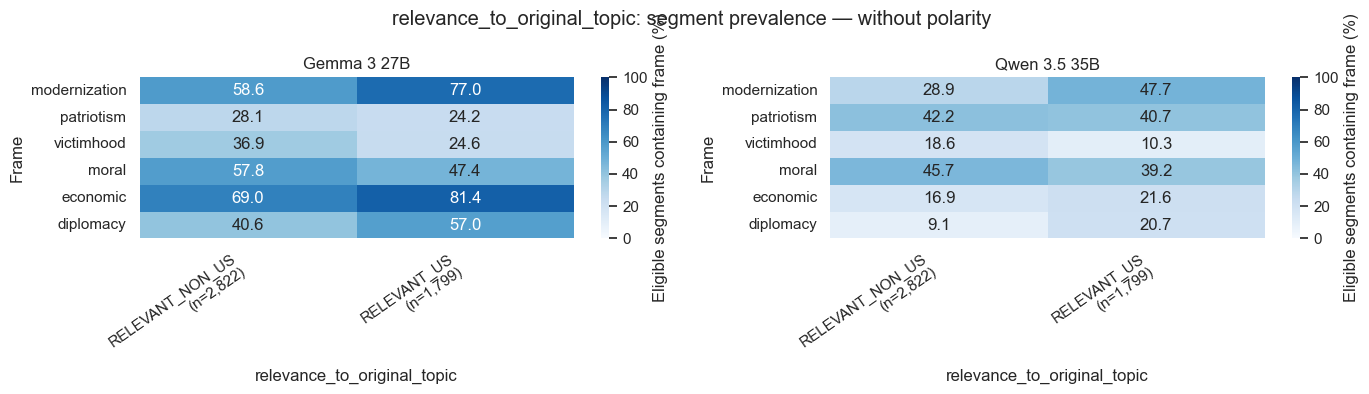

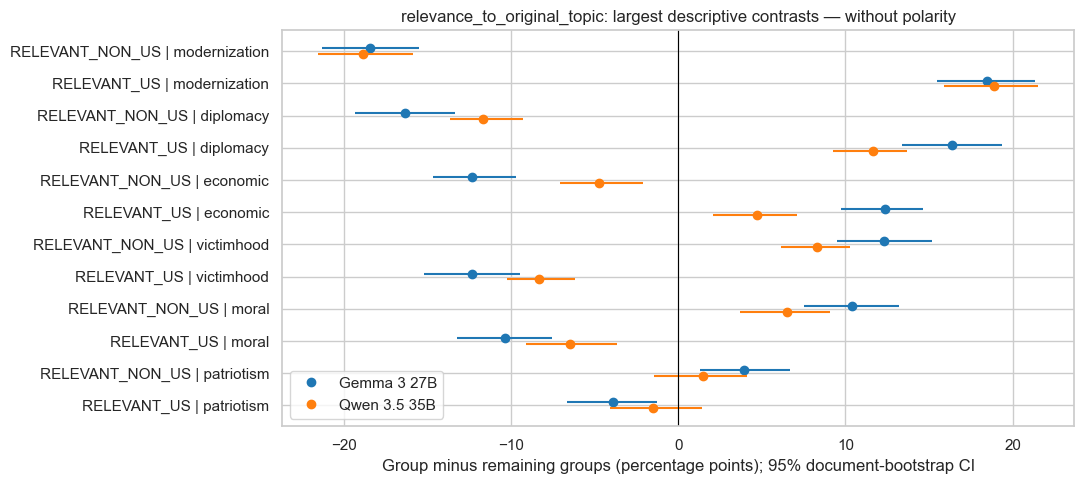

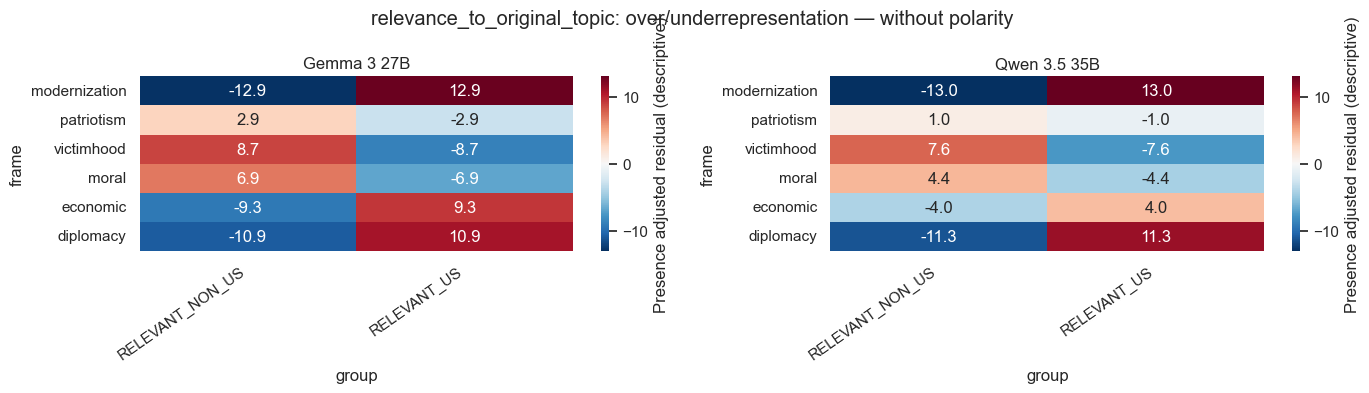

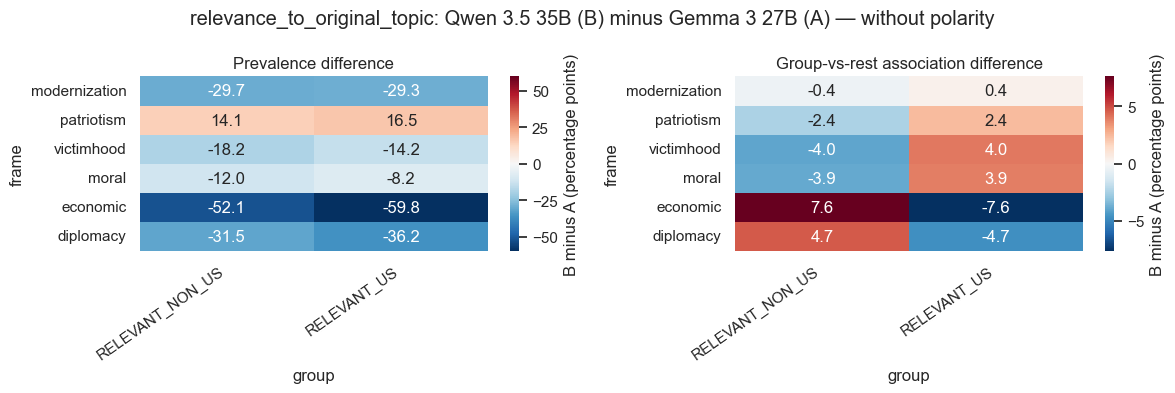

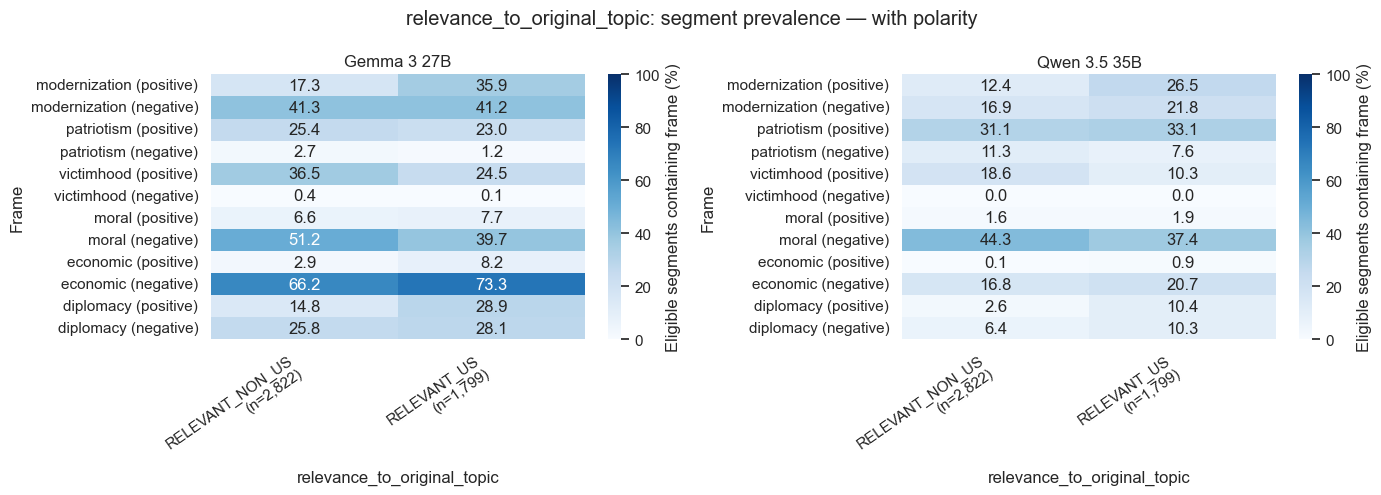

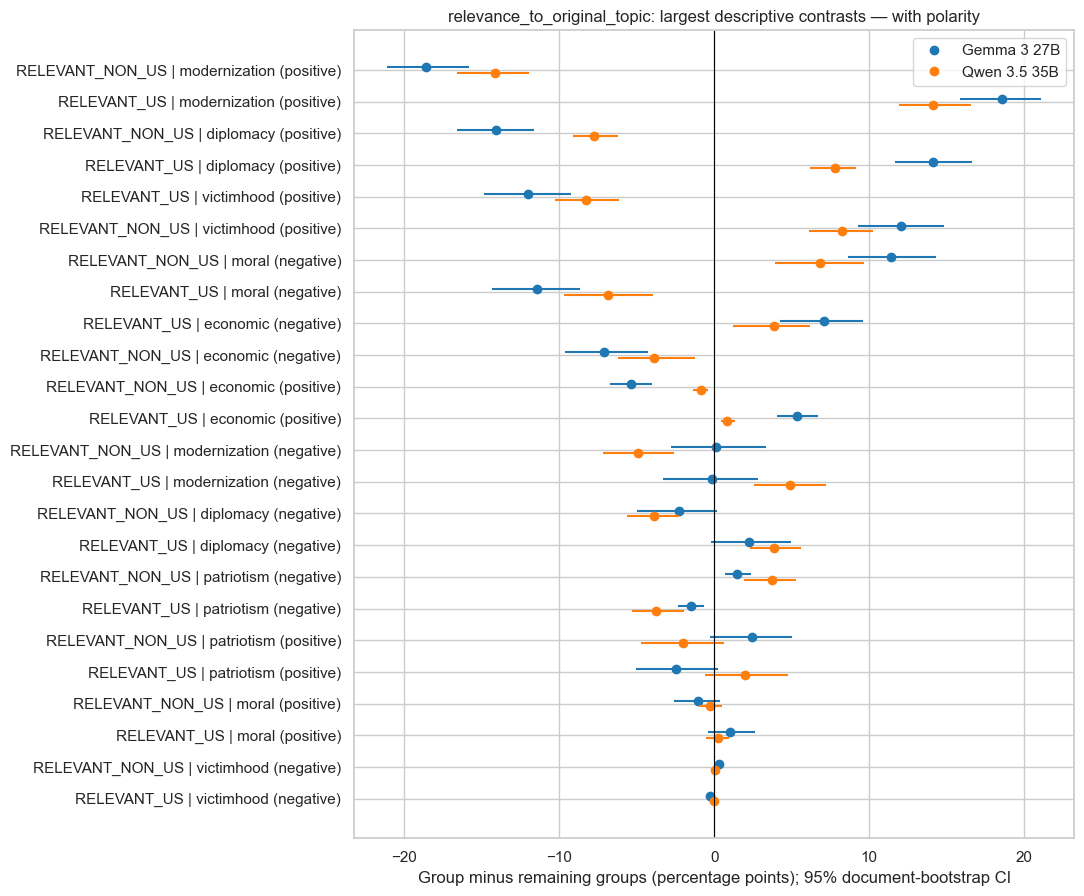

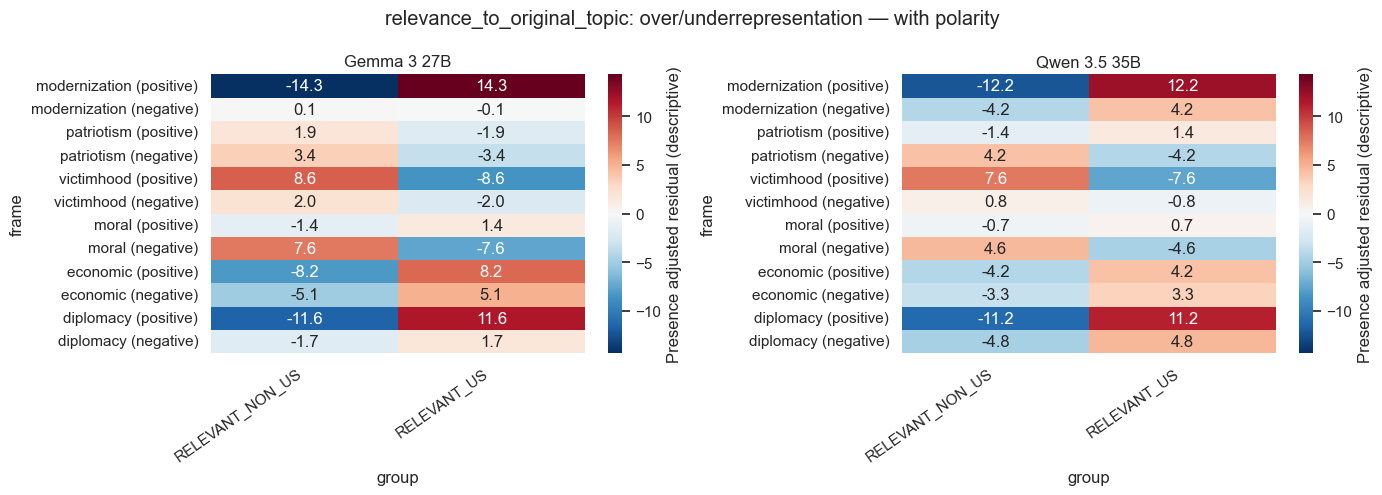

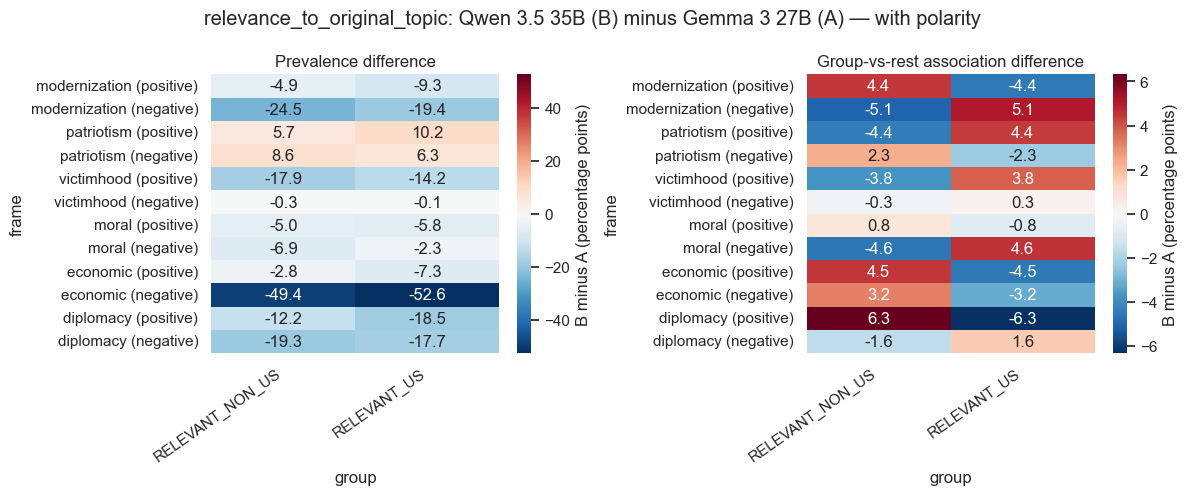

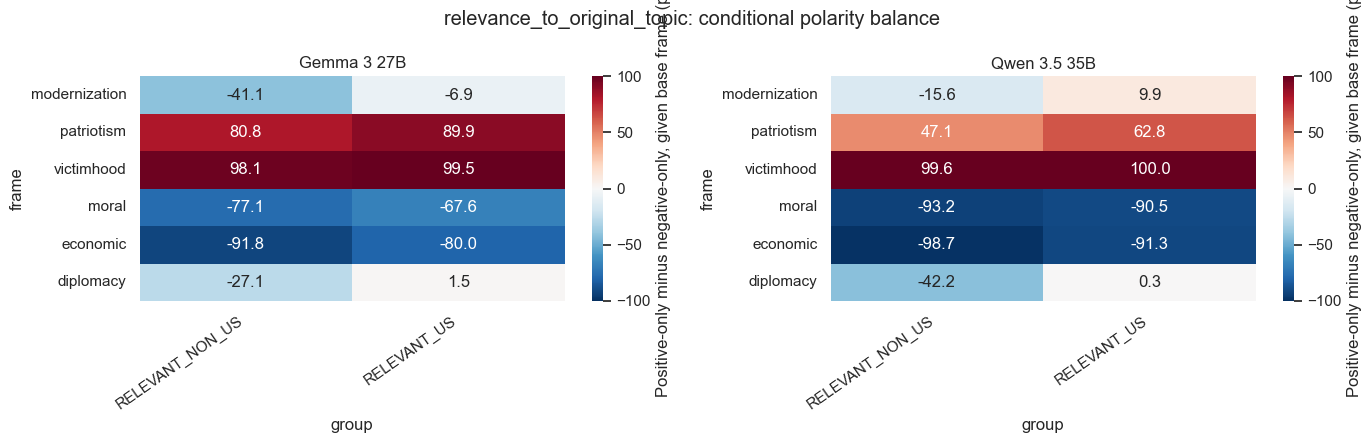

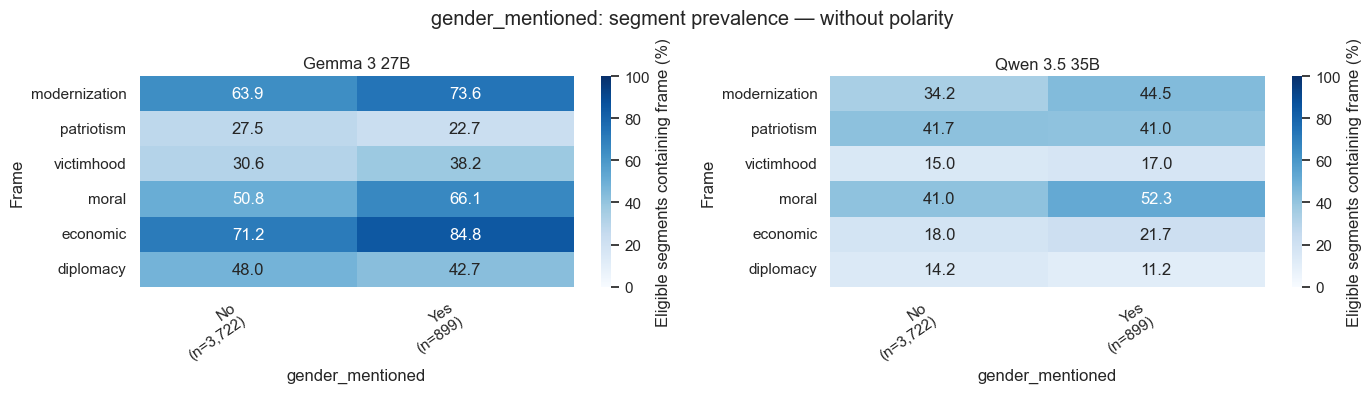

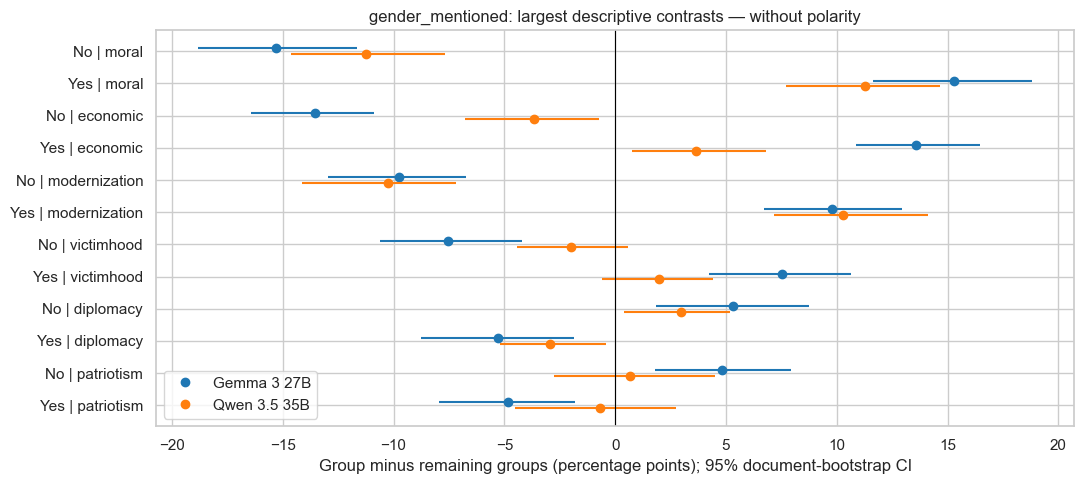

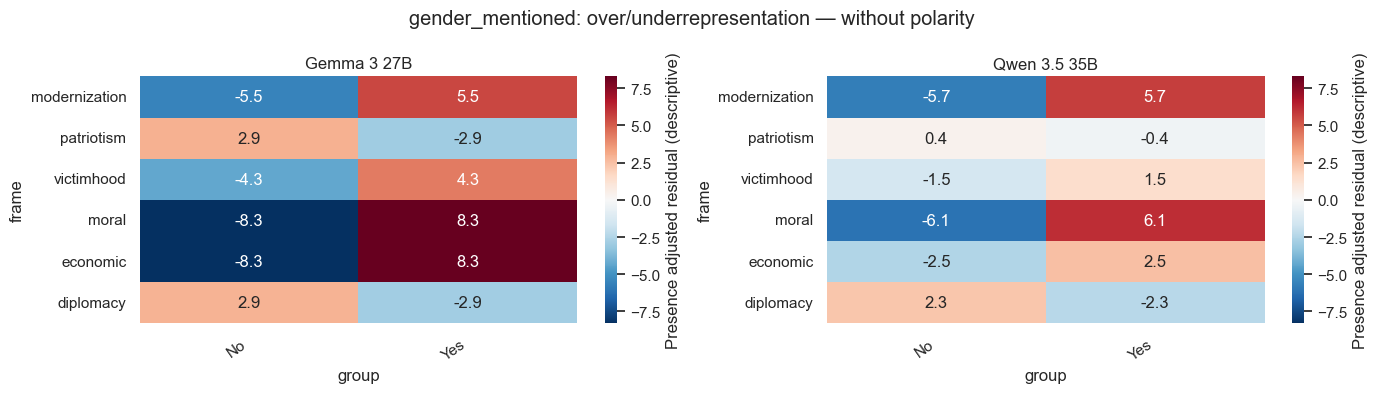

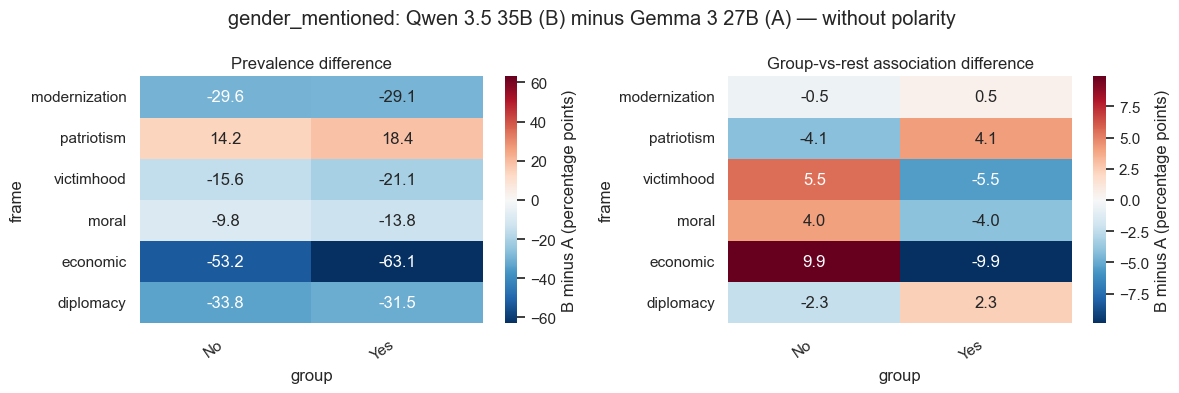

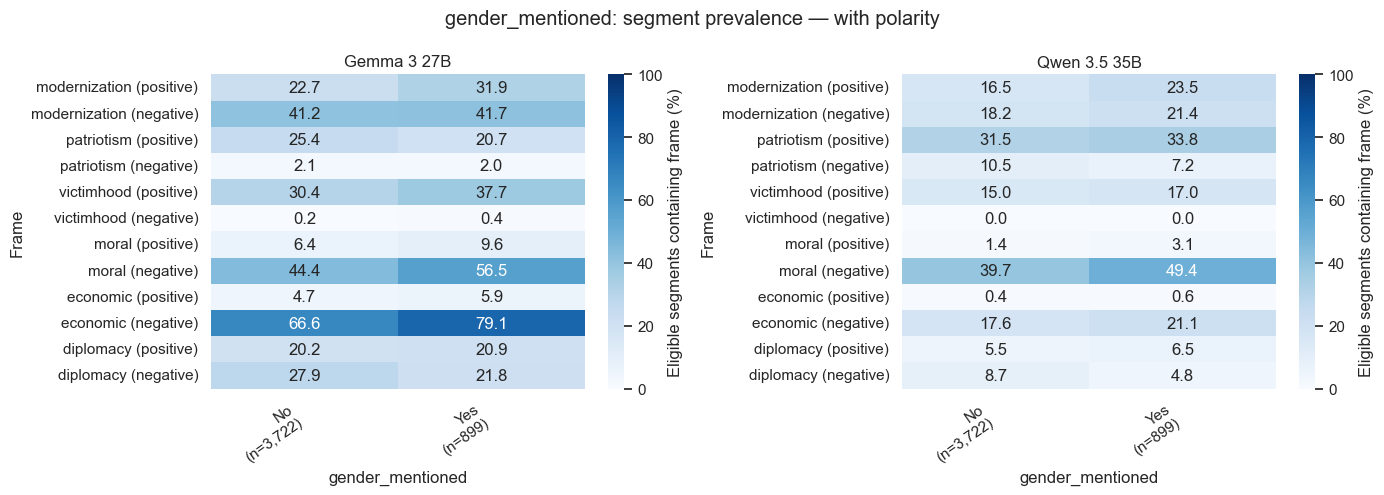

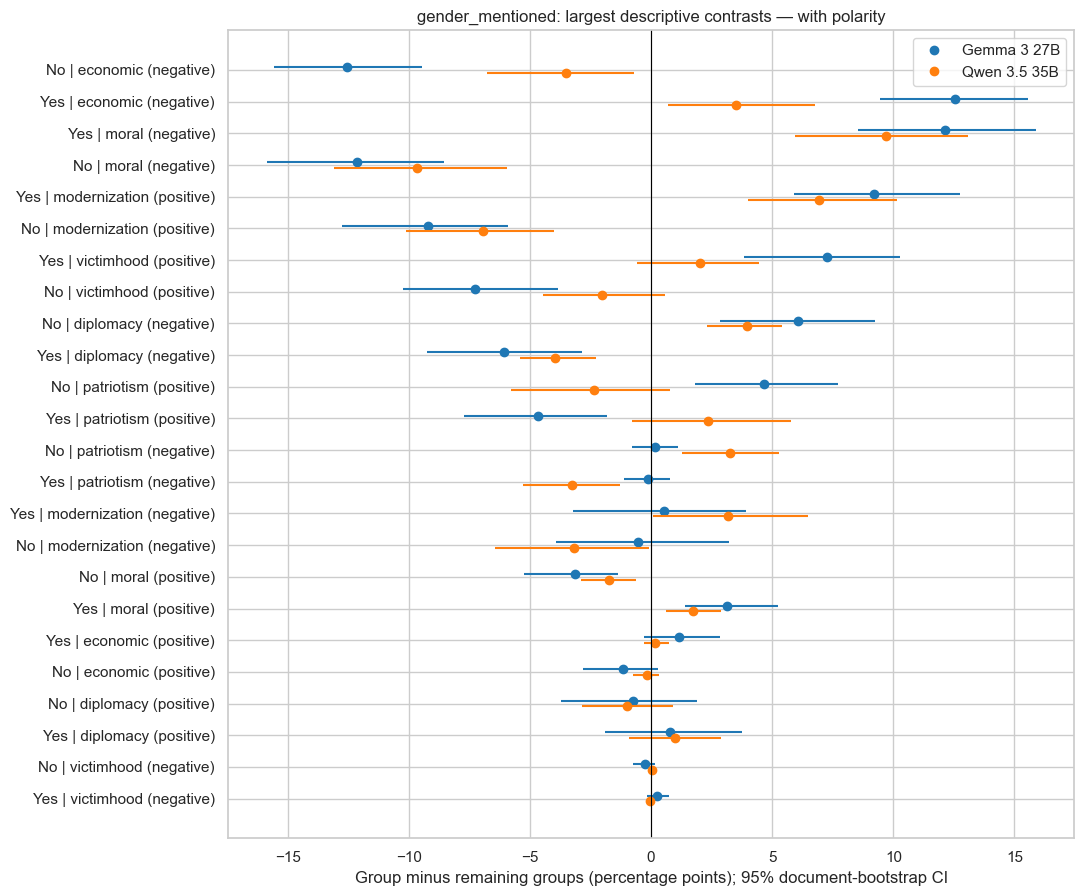

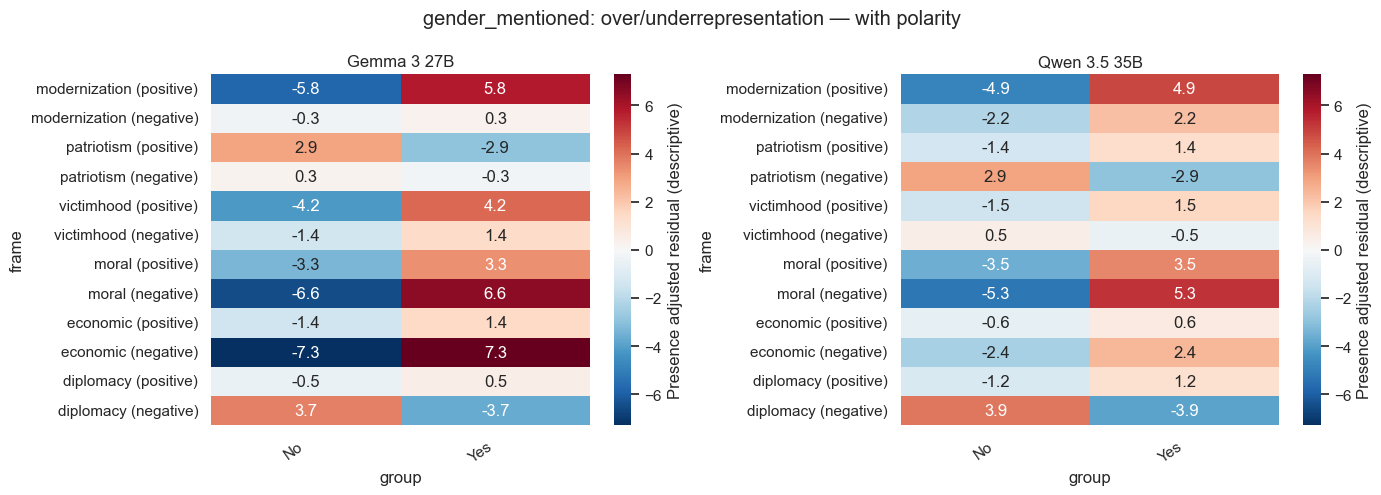

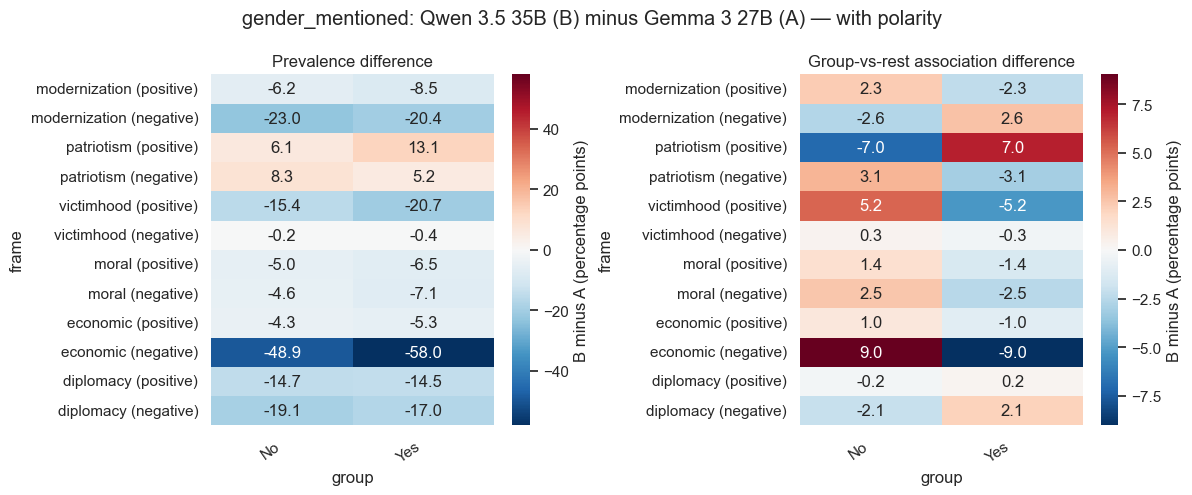

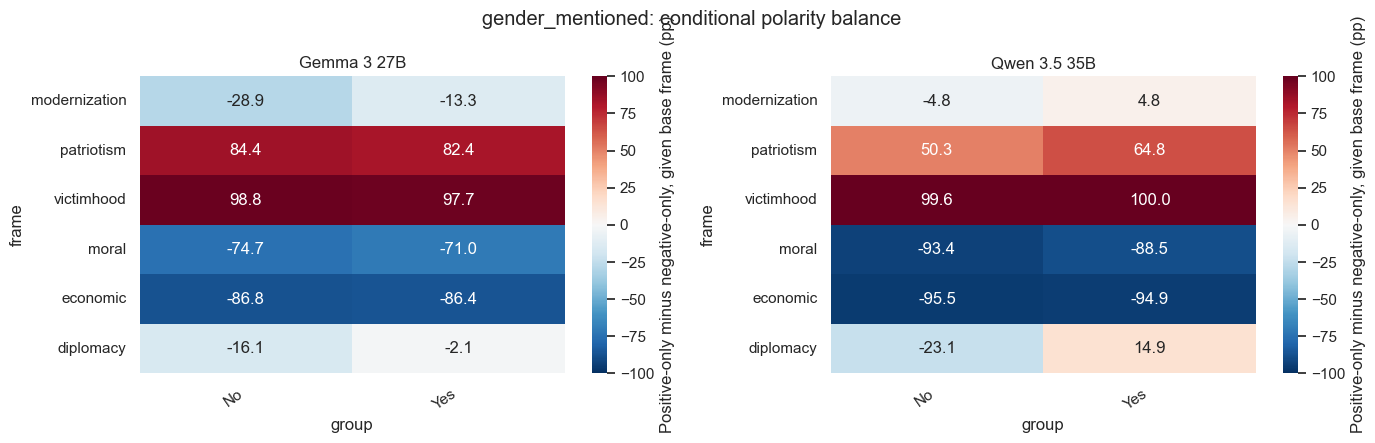

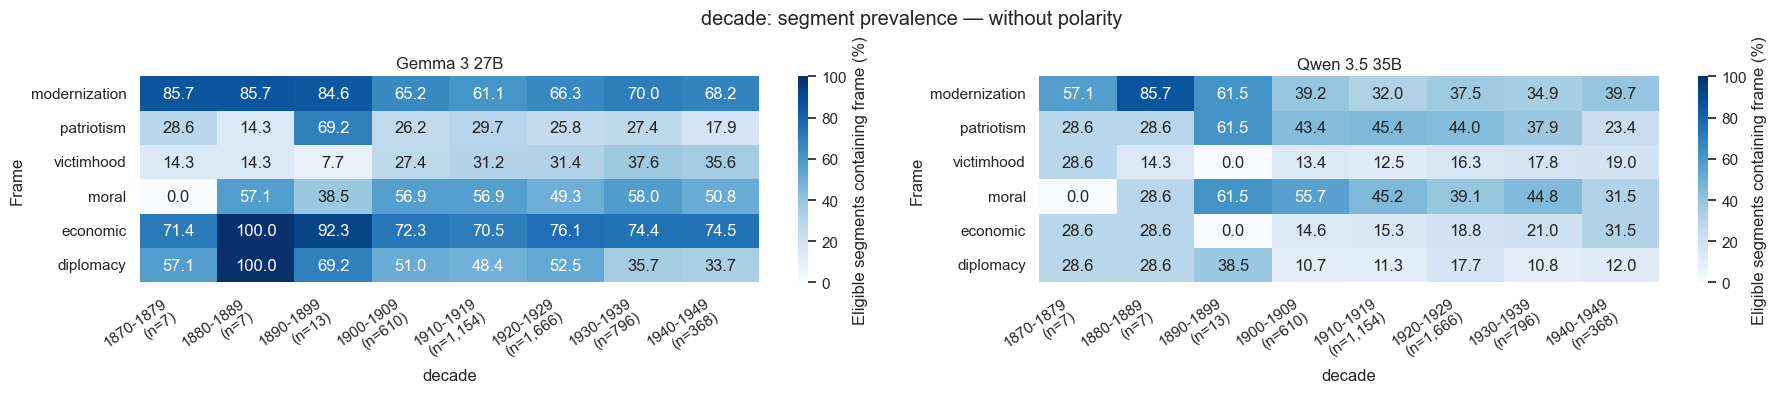

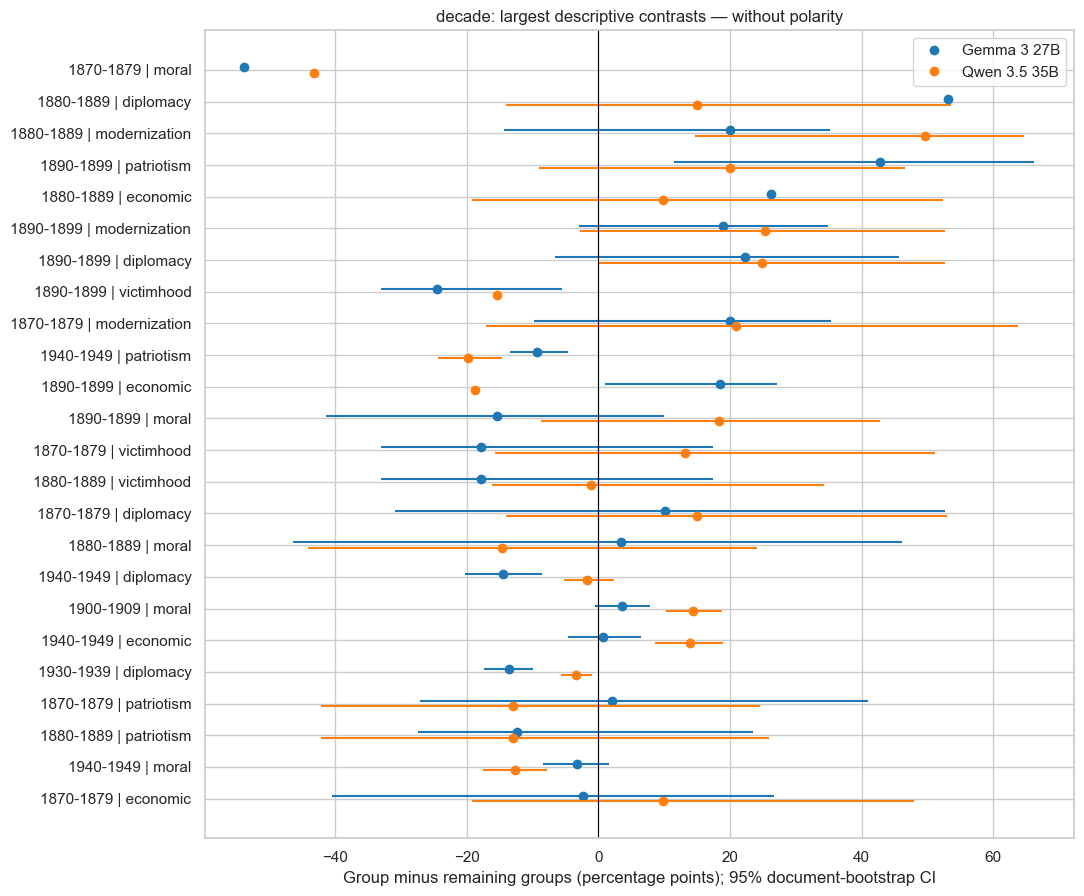

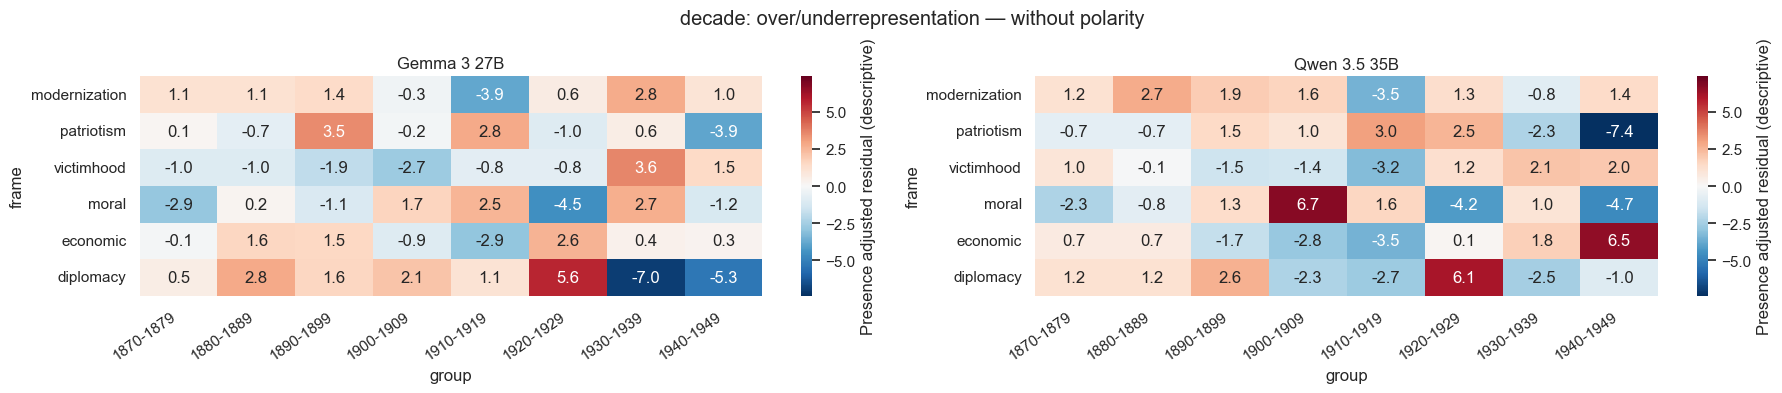

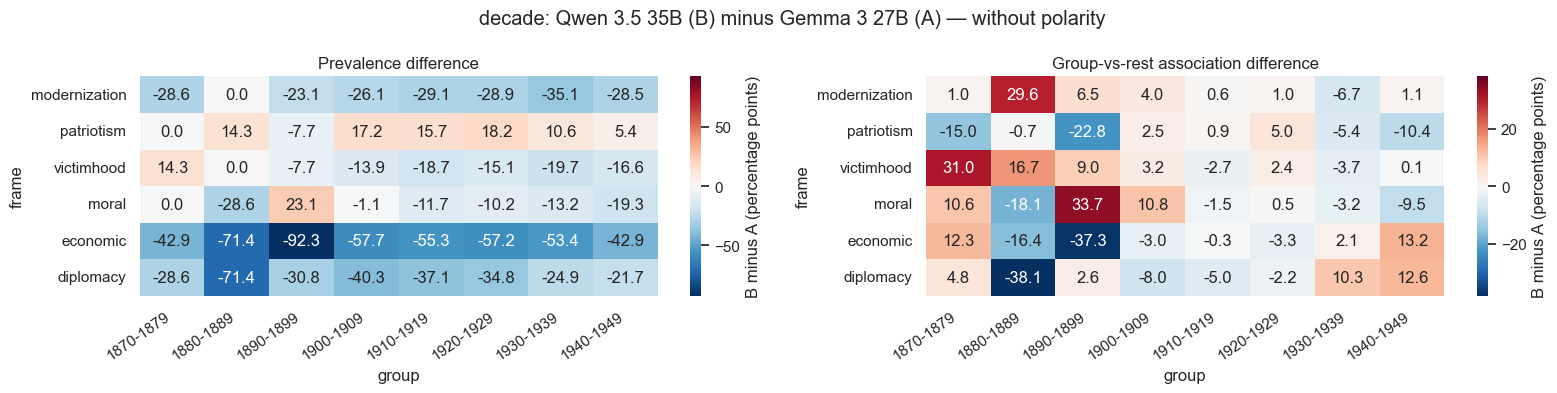

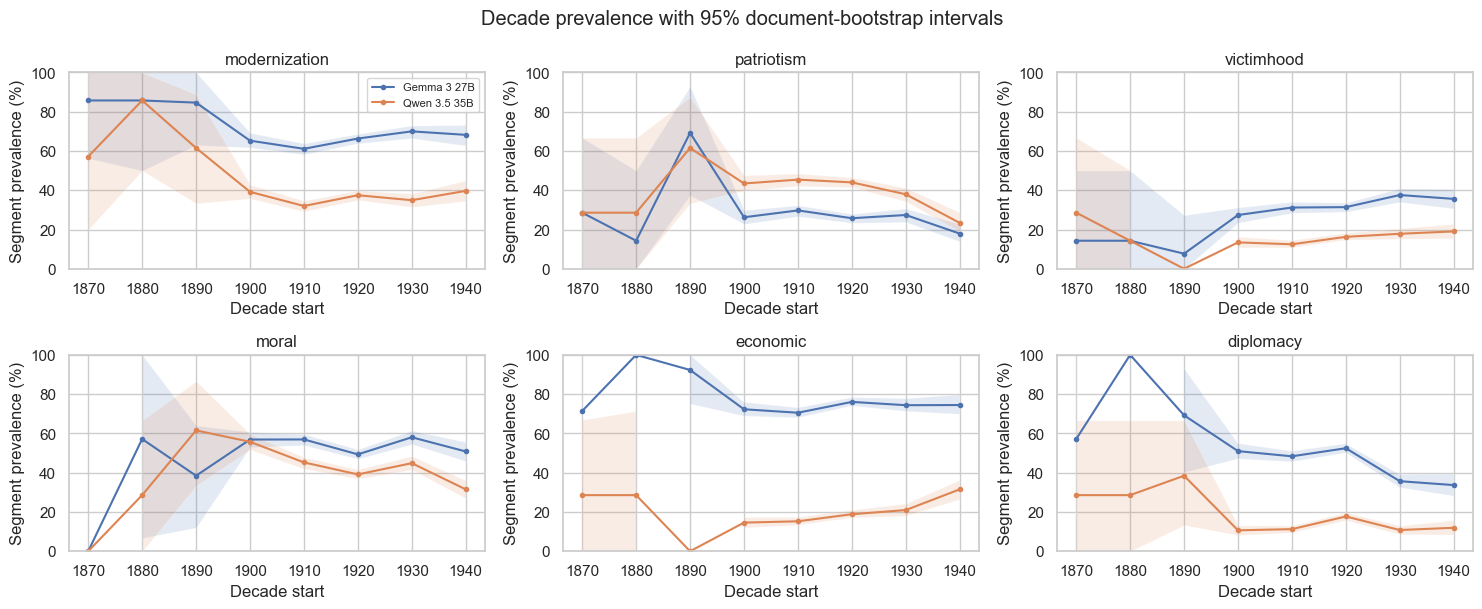

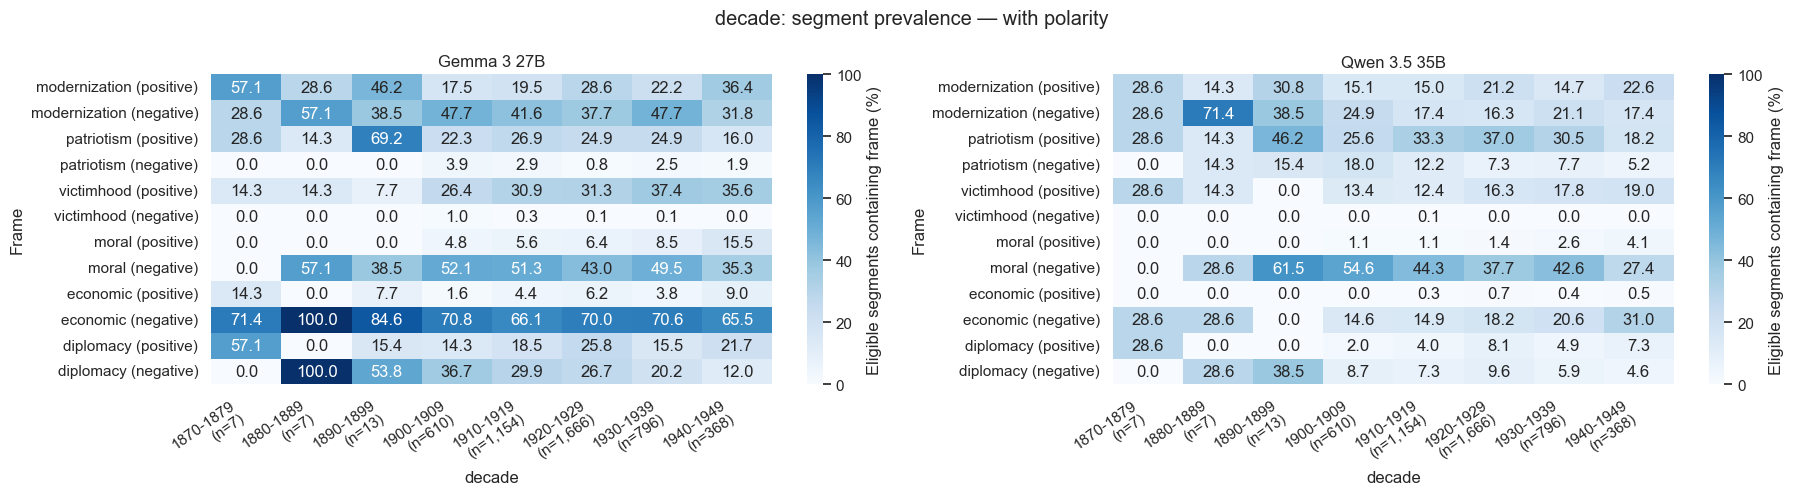

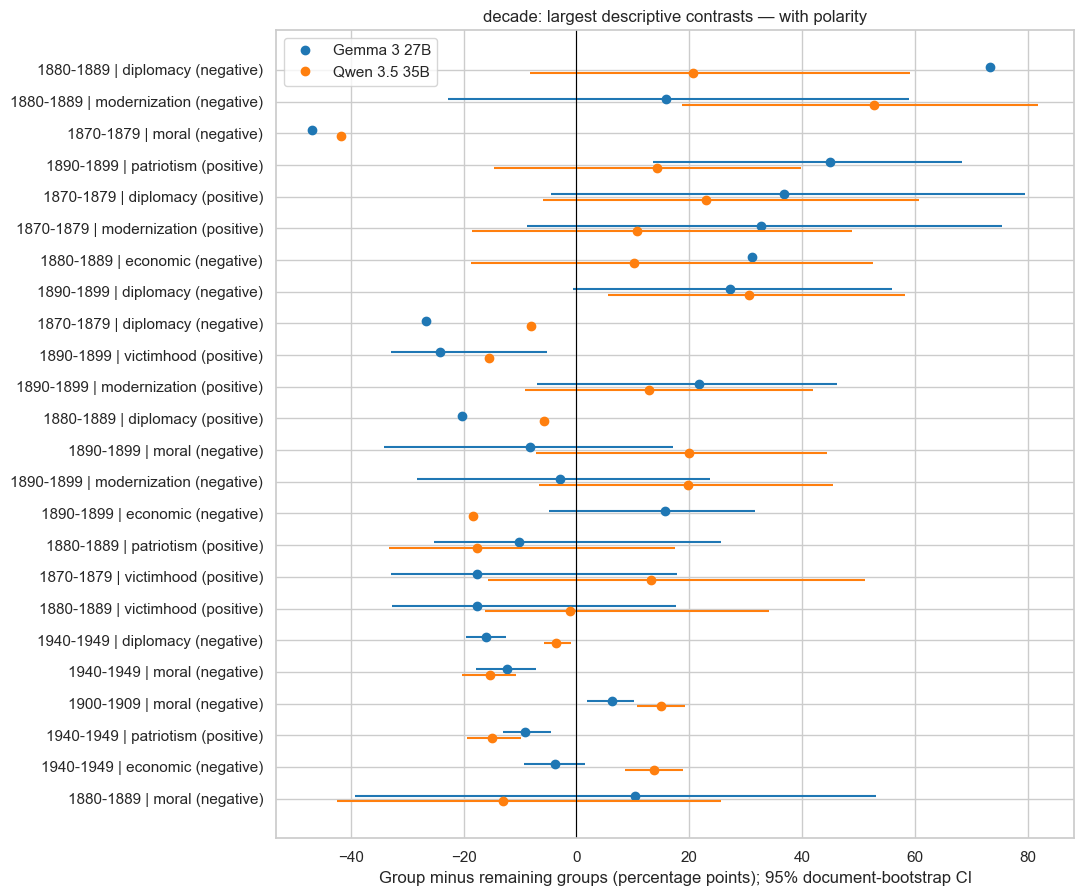

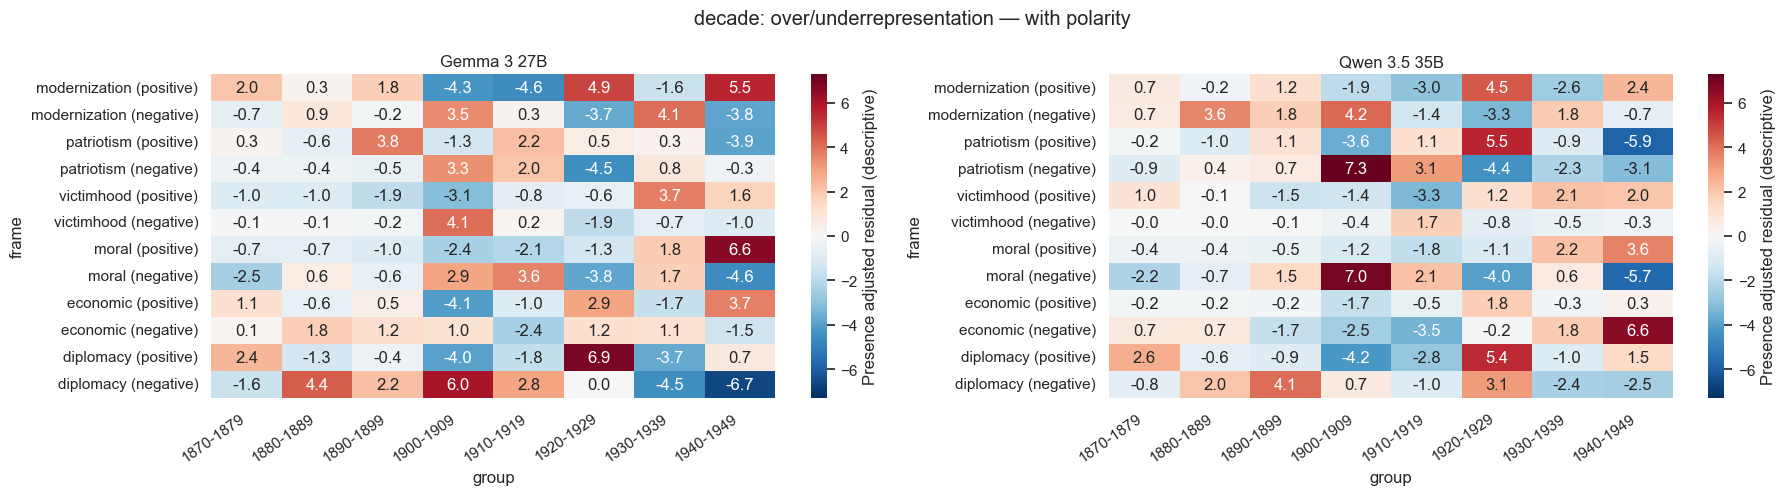

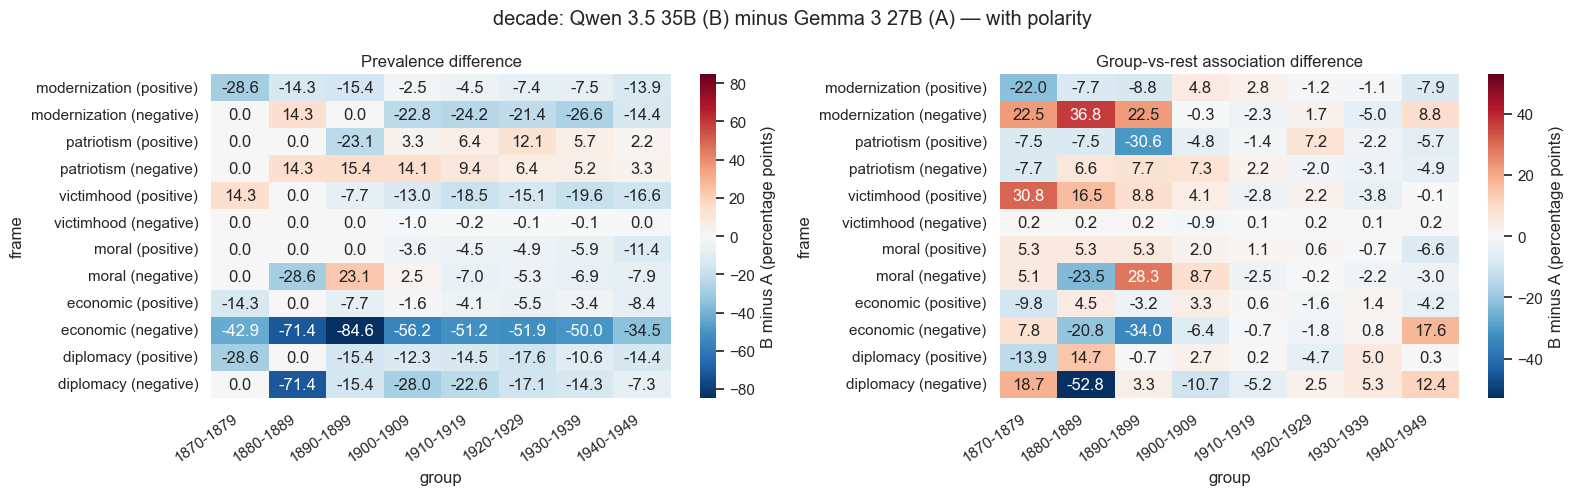

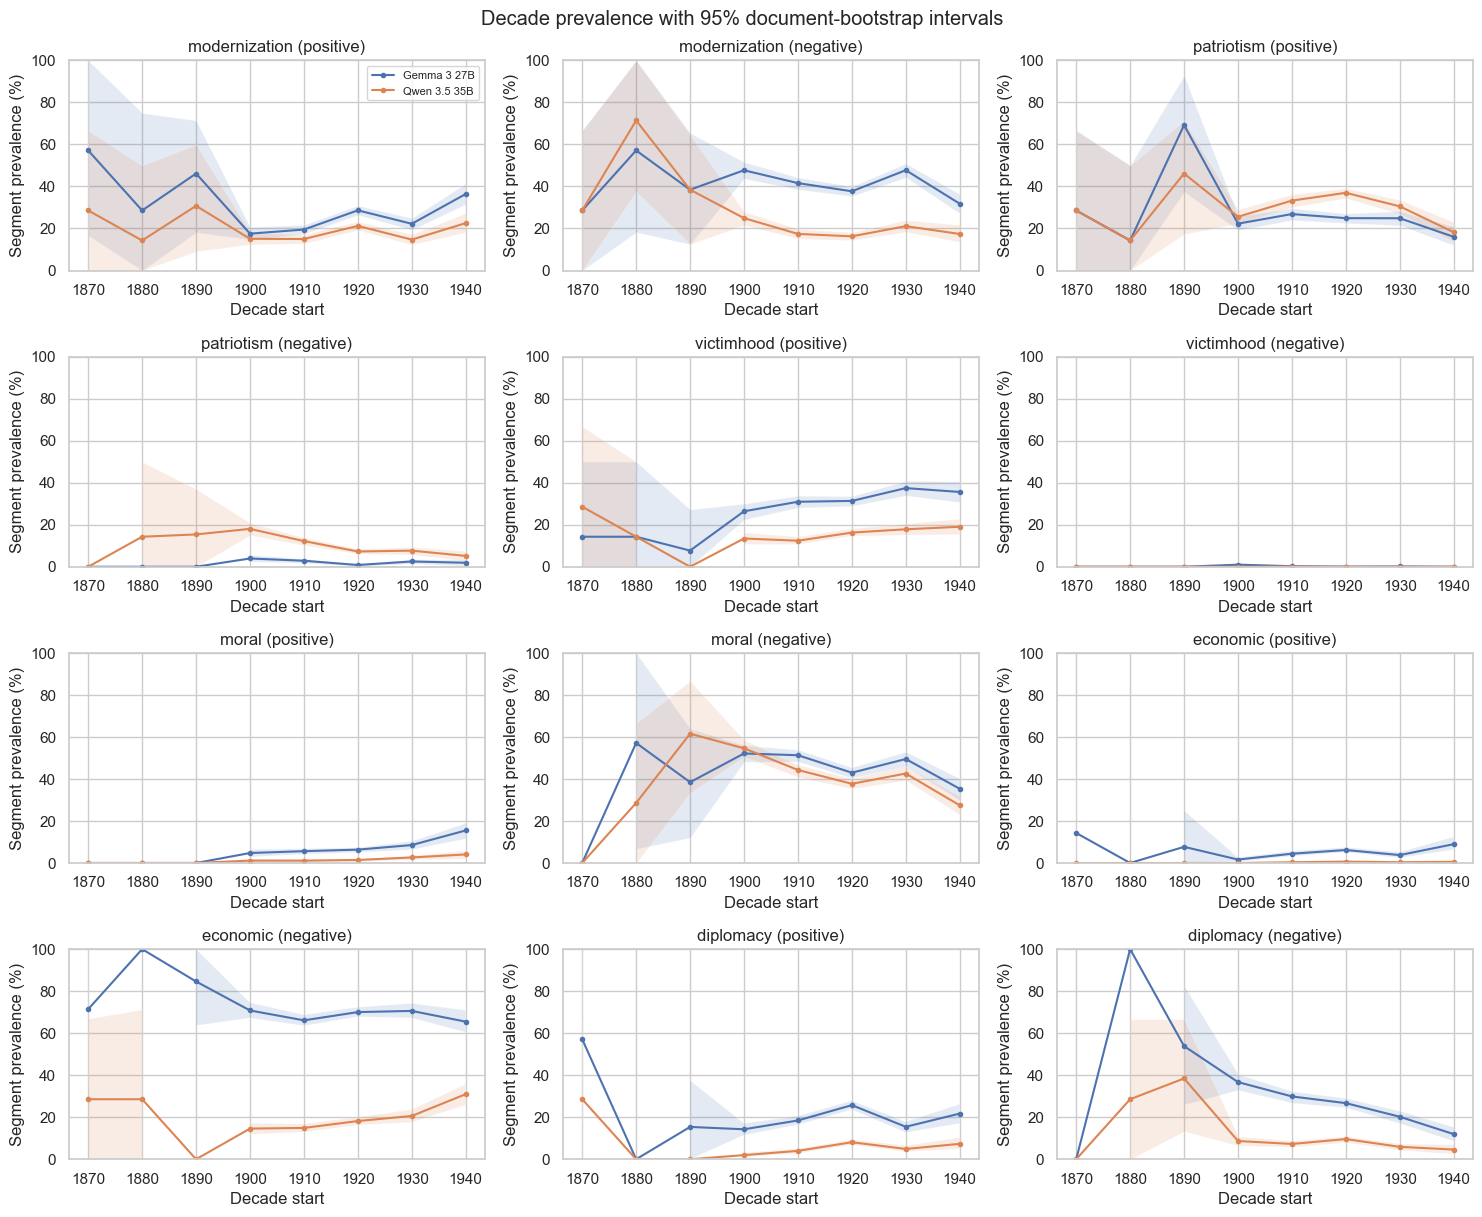

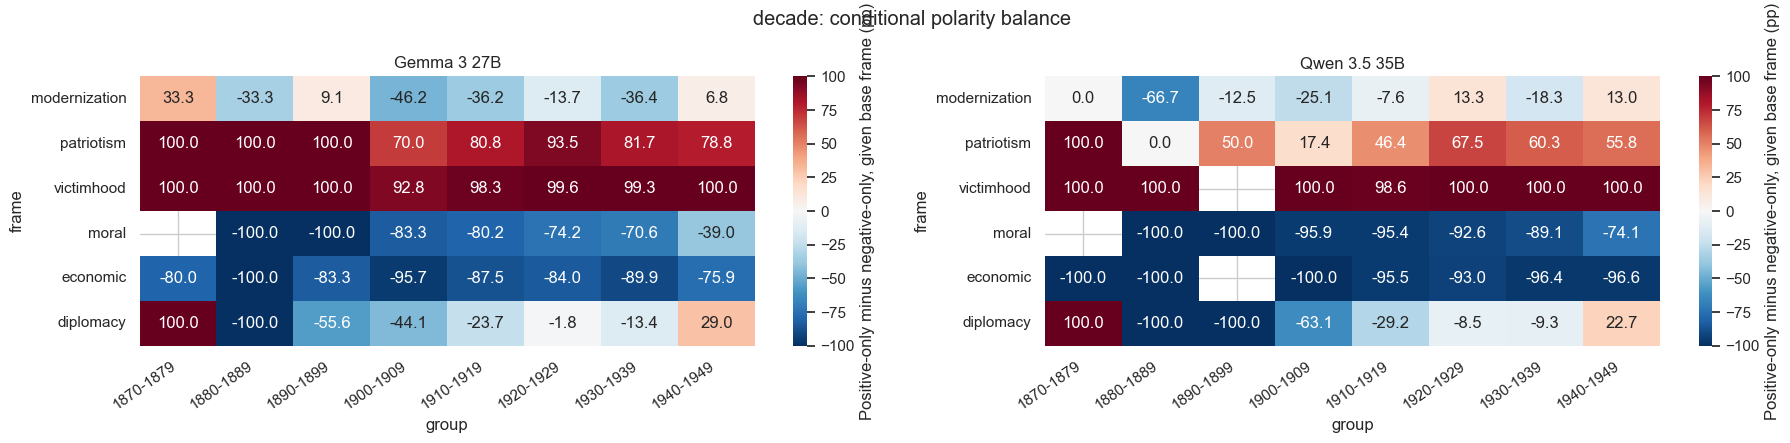

29 new figures saved.


In [12]:
assoc_plot_files=[]
def assoc_slug(value):
    return re.sub(r'[^A-Za-z0-9_-]+','_',str(value))[:70]+'_'+hashlib.sha1(str(value).encode()).hexdigest()[:6]

def assoc_finish(fig,name):
    path=assoc_out/name;fig.savefig(path,dpi=180,bbox_inches='tight');assoc_plot_files.append(name)
    plt.show();plt.close(fig)

def assoc_matrix(data,model,levels,frames,value):
    return data.loc[data.model.eq(model)].pivot(index='frame',columns='group',values=value).reindex(index=frames,columns=levels)

if ASSOC_MAKE_PLOTS and not assoc_prevalence.empty:
    for variable,cache in assoc_group_cache.items():
        levels=cache['levels'][:ASSOC_MAX_PLOT_LEVELS]
        if len(cache['levels'])>len(levels):print(f'{variable}: figures show first {len(levels)} sorted categories; CSVs retain all.')
        for mode,frames in [('without_polarity',FRAME_NAMES),('with_polarity',FRAME_TYPE_ORDER)]:
            data=assoc_prevalence.loc[assoc_prevalence.variable.eq(variable)&assoc_prevalence['mode'].eq(mode)]
            prefix=f'{assoc_slug(variable)}_{mode}'
            fig,axes=plt.subplots(1,len(assoc_models),figsize=(max(7,len(levels)*1.15)*len(assoc_models),max(4,len(frames)*.42)),squeeze=False)
            for ax,model in zip(axes.ravel(),assoc_models):
                mat=assoc_matrix(data,model,levels,frames,'prevalence_pct')
                sns.heatmap(mat,ax=ax,cmap='Blues',vmin=0,vmax=100,annot=len(levels)<=8,fmt='.1f',
                            cbar_kws={'label':'Eligible segments containing frame (%)'})
                den=data.loc[data.model.eq(model)].groupby('group').n_segments.first()
                ax.set_xticklabels([f'{g}\n(n={int(den[g]):,})' for g in levels],rotation=35,ha='right')
                ax.set_title(model);ax.set_ylabel('Frame');ax.set_xlabel(variable)
            fig.suptitle(f'{variable}: segment prevalence — {mode.replace("_"," ")}');fig.tight_layout()
            assoc_finish(fig,prefix+'_prevalence.png')

            # Ranked, descriptive group-vs-rest effects with paired-cluster bootstrap CIs.
            ranked=data.assign(_strength=data.difference_vs_rest_pp.abs()).groupby(['group','frame'])._strength.max().nlargest(24).index
            ranked=list(ranked)
            if ranked:
                fig,ax=plt.subplots(figsize=(11,max(5,len(ranked)*.38)))
                colors=sns.color_palette('tab10',len(assoc_models))
                for j,model in enumerate(assoc_models):
                    indexed=data.loc[data.model.eq(model)].set_index(['group','frame'])
                    for i,key in enumerate(ranked):
                        r=indexed.loc[key];y=i+(j-(len(assoc_models)-1)/2)*.18
                        if pd.notna(r.difference_vs_rest_pp):
                            ax.plot(r.difference_vs_rest_pp,y,'o',color=colors[j],label=model if i==0 else None)
                            if pd.notna(r.difference_ci_low) and pd.notna(r.difference_ci_high):
                                ax.hlines(y,r.difference_ci_low,r.difference_ci_high,color=colors[j],linewidth=1.5)
                ax.axvline(0,color='black',lw=.8);ax.set_yticks(range(len(ranked)),[f'{g} | {f}' for g,f in ranked])
                ax.invert_yaxis();ax.set_xlabel('Group minus remaining groups (percentage points); 95% document-bootstrap CI')
                ax.set_title(f'{variable}: largest descriptive contrasts — {mode.replace("_"," ")}');ax.legend();fig.tight_layout()
                assoc_finish(fig,prefix+'_effects.png')

            res=assoc_residuals.loc[assoc_residuals.variable.eq(variable)&assoc_residuals['mode'].eq(mode)] if not assoc_residuals.empty else pd.DataFrame()
            if not res.empty:
                limit=max(1,float(res.presence_adjusted_residual.abs().max()))
                fig,axes=plt.subplots(1,len(assoc_models),figsize=(max(7,len(levels)*1.15)*len(assoc_models),max(4,len(frames)*.42)),squeeze=False)
                for ax,model in zip(axes.ravel(),assoc_models):
                    mat=assoc_matrix(res,model,levels,frames,'presence_adjusted_residual')
                    sns.heatmap(mat,ax=ax,cmap='RdBu_r',center=0,vmin=-limit,vmax=limit,
                                annot=len(levels)<=8,fmt='.1f',cbar_kws={'label':'Presence adjusted residual (descriptive)'})
                    ax.set_title(model);ax.set_xticklabels(ax.get_xticklabels(),rotation=35,ha='right')
                fig.suptitle(f'{variable}: over/underrepresentation — {mode.replace("_"," ")}');fig.tight_layout()
                assoc_finish(fig,prefix+'_residuals.png')

            if not assoc_model_differences.empty:
                diff=assoc_model_differences.loc[assoc_model_differences.variable.eq(variable)&assoc_model_differences['mode'].eq(mode)]
                for (ma,mb),sub in diff.groupby(['model_a','model_b']):
                    fig,axes=plt.subplots(1,2,figsize=(max(12,len(levels)*2),max(4,len(frames)*.42)))
                    for ax,col,title in zip(axes,['model_b_minus_a_pp','association_difference_b_minus_a_pp'],['Prevalence difference','Group-vs-rest association difference']):
                        mat=sub.pivot(index='frame',columns='group',values=col).reindex(index=frames,columns=levels)
                        limit=max(1,float(np.nanmax(np.abs(mat.to_numpy())))) if np.isfinite(mat.to_numpy()).any() else 1
                        sns.heatmap(mat,ax=ax,cmap='RdBu_r',center=0,vmin=-limit,vmax=limit,annot=len(levels)<=8,fmt='.1f',cbar_kws={'label':'B minus A (percentage points)'})
                        ax.set_title(title);ax.set_xticklabels(ax.get_xticklabels(),rotation=35,ha='right')
                    fig.suptitle(f'{variable}: {mb} (B) minus {ma} (A) — {mode.replace("_"," ")}');fig.tight_layout()
                    assoc_finish(fig,prefix+f'_model_difference_{assoc_slug(ma+mb)}.png')

            if variable=='decade':
                fig,axes=plt.subplots(int(np.ceil(len(frames)/3)),3,figsize=(15,3.1*int(np.ceil(len(frames)/3))),squeeze=False)
                for ax,frame in zip(axes.ravel(),frames):
                    for model in assoc_models:
                        line=data.loc[data.frame.eq(frame)&data.model.eq(model)].sort_values('group')
                        x=line.group.str[:4].astype(int).to_numpy();y=line.prevalence_pct.to_numpy()
                        ax.plot(x,y,'o-',label=model,markersize=3)
                        ax.fill_between(x,line.prevalence_ci_low.to_numpy(float),line.prevalence_ci_high.to_numpy(float),alpha=.15)
                    ax.set_title(frame);ax.set_ylim(0,100);ax.set_xlabel('Decade start');ax.set_ylabel('Segment prevalence (%)')
                axes.ravel()[0].legend(fontsize=8);fig.suptitle('Decade prevalence with 95% document-bootstrap intervals');fig.tight_layout()
                assoc_finish(fig,prefix+'_trajectories.png')

        conditional=assoc_conditional.loc[assoc_conditional.variable.eq(variable)]
        fig,axes=plt.subplots(1,len(assoc_models),figsize=(max(7,len(levels)*1.15)*len(assoc_models),4.5),squeeze=False)
        for ax,model in zip(axes.ravel(),assoc_models):
            mat=assoc_matrix(conditional,model,levels,FRAME_NAMES,'net_polarity_balance_pp')
            sns.heatmap(mat,ax=ax,cmap='RdBu_r',center=0,vmin=-100,vmax=100,annot=len(levels)<=8,fmt='.1f',
                        cbar_kws={'label':'Positive-only minus negative-only, given base frame (pp)'})
            ax.set_title(model);ax.set_xticklabels(ax.get_xticklabels(),rotation=35,ha='right')
        fig.suptitle(f'{variable}: conditional polarity balance');fig.tight_layout()
        assoc_finish(fig,f'{assoc_slug(variable)}_conditional_polarity.png')

        if not assoc_coefficients.empty:
            co=assoc_coefficients.loc[assoc_coefficients.variable.eq(variable)].copy()
            co=co.loc[np.isfinite(co.or_ci_low)&np.isfinite(co.or_ci_high)&co.or_ci_low.gt(0)&co.or_ci_high.gt(0)]
            co=co.assign(_strength=co.log_odds.abs()).nlargest(24,'_strength')
            if len(co):
                fig,ax=plt.subplots(figsize=(12,max(5,len(co)*.4)))
                for i,(_,r) in enumerate(co.iterrows()):
                    ax.hlines(i,r.or_ci_low,r.or_ci_high,color='#286d96');ax.plot(r.adjusted_odds_ratio,i,'o',color='#286d96')
                ax.set_yticks(range(len(co)),[f'{r.model} | {r.frame} | {r.contrast}' for _,r in co.iterrows()]);ax.invert_yaxis()
                ax.set_xscale('log');ax.axvline(1,color='black',lw=.8);ax.set_xlabel('Adjusted odds ratio, log scale; 95% document-clustered CI')
                ax.set_title(f'{variable}: largest fitted log-odds contrasts (jointly adjusted)');fig.tight_layout()
                assoc_finish(fig,f'{assoc_slug(variable)}_adjusted_odds_ratios.png')
print(f'{len(assoc_plot_files)} new figures saved.')


### Export provenance and reading guide

Start with coverage, missing/conflicting metadata and prediction-quality diagnostics. Then compare group prevalences and document-bootstrap intervals, followed by group-vs-rest effect sizes. Use clustered FDR-adjusted omnibus tests for statistical evidence; inspect adjusted tests and reference-level odds ratios for associations conditional on the other predictors. Use interaction tests and paired association-difference estimates to compare models. A model discrepancy is not evidence that one model is more accurate.

Use iid contingency tests/residuals as diagnostics, not independent-document evidence. Rare outcomes and few-document groups may have no trustworthy inferential result. Results are exploratory; follow-up comparisons should be planned and validated on an independent sample where possible. Model-generated gender/relevance variables, if applicable, may share measurement errors with framing outputs.

All new CSVs use UTF-8 with BOM. Files are overwritten by subsequent runs. A fresh output directory avoids stale figures after changing options. The original legacy incidence plots and association tables remain in the earlier sections; their denominators differ from the new segment-level tables.

In [13]:
from datetime import datetime, timezone
versions={}
for package in ['pandas','numpy','scipy','statsmodels','matplotlib','seaborn']:
    try:versions[package]=importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:versions[package]=None
provenance={'created_utc':datetime.now(timezone.utc).isoformat(),'input_files':[str(Path(p).resolve()) for p in discovered],
            'models':assoc_models,'reference_model_metadata':assoc_reference,'join_keys':assoc_keys,
            'matched_analysis_segments':len(common),'document_clusters':len(clusters),'cluster_column':cluster_column,
            'variables':ASSOC_VARIABLES,'references':reference_levels,'bootstrap_replicates':B,'seed':ASSOC_SEED,
            'bootstrap_method':'whole-document resampling, paired across all models, percentile 95%',
            'primary_population':'valid matched predictions across all models, matching text/document identifiers',
            'metadata_policy':'reference model values; per-variable complete cases; conflicting values excluded',
            'missing_tokens':sorted(assoc_missing),'min_clusters_for_robust_tests':ASSOC_MIN_CLUSTERS,
            'min_success_failure_per_category':ASSOC_MIN_CELL,'alpha':ASSOC_ALPHA,'adjusted_models':ASSOC_ADJUSTED_MODELS,
            'fdr_families':['all clustered unadjusted omnibus','all clustered adjusted omnibus','all clustered model interactions','all iid diagnostics'],
            'decade_definition':'calendar decades from integer year with YYYYMMDD/ISO date fallback',
            'packages':versions,'figure_files':assoc_plot_files}
(assoc_out/'association_provenance.json').write_text(json.dumps(provenance,ensure_ascii=False,indent=2),encoding='utf-8')
readme=['Metadata association outputs',
'1. association_coverage.csv, metadata_conflicts.csv, prediction_quality.csv, matched_segment_metadata.csv: audit eligibility and denominators.',
'2. group_frame_prevalence.csv: counts, prevalence, cluster-bootstrap intervals, lift, group-vs-rest effects and descriptive odds ratios.',
'3. clustered_unadjusted_tests.csv: omnibus predictor associations with document clustering and BH-FDR.',
'4. clustered_adjusted_tests.csv and adjusted_odds_ratios.csv: joint adjustment for relevance, gender and decade.',
'5. paired_model_differences.csv and clustered_model_interaction_tests.csv: paired model prevalence and association differences.',
'6. conditional_polarity_by_group.csv: polarity distributions among segments containing each base frame.',
'7. iid_association_diagnostics.csv and presence_residuals.csv: contingency diagnostics, not document-clustered inference.',
'8. all_eligible_sensitivity.csv: own-model eligible populations; denominators may differ.',
'9. PNGs: saved visualizations; association_provenance.json: reproducibility settings.',
'Intervals are pointwise. Skipped tests are not evidence of no association. All analyses are associational, not causal.',
f'Matched segments: {len(common):,}; documents: {len(clusters):,}; metadata reference: {assoc_reference}.']
(assoc_out/'README.txt').write_text('\n'.join(readme)+'\n',encoding='utf-8')
print(f'New metadata analyses saved to: {assoc_out.resolve()}')
display(pd.DataFrame([{'file':p.name,'size_kb':round(p.stat().st_size/1024,1)} for p in sorted(assoc_out.iterdir()) if p.is_file()]))


New metadata analyses saved to: /Users/carmand/Desktop/framing/analysis_outputs/metadata_associations


,file,size_kb
0,README.txt,1.2
1,adjusted_odds_ratios.csv,0.1
2,all_eligible_sensitivity.csv,46.3
3,association_coverage.csv,0.3
4,association_provenance.json,3.5
5,clustered_adjusted_tests.csv,13.1
6,clustered_model_interaction_tests.csv,8.2
7,clustered_unadjusted_tests.csv,15.1
8,conditional_polarity_by_group.csv,15.2
9,decade_964ec4_conditional_polarity.png,233.8
